# VaR and Backtesting — MFE230H Problem Set 2

**Notebook 1: Questions 1–6**

This notebook covers:

1. Portfolio construction
2. Parametric VaR
   - Variance–covariance VaR
   - One-factor model
3. Historical-simulation VaR
4. Marginal VaR
5. Bootstrap confidence interval
6. Repeating Questions 3–5 with a 500-day rolling window

All figures and tables are saved automatically to the project `results/` folder.

## 0. Project setup

The project root is detected automatically by searching upward for `pyproject.toml`.

Expected project structure:

```text
VaR_Backtesting_as2/
├── ass/
├── data/
│   ├── raw/
│   └── processed/
├── notebooks/
├── report/
├── results/
│   ├── figures/
│   └── tables/
├── src/
├── pyproject.toml
└── uv.lock
```

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import yfinance as yf

warnings.filterwarnings("ignore")

def find_project_root(start=None):
    # Search upward for pyproject.toml and return the project root.
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError(
        "Could not find pyproject.toml. Open this notebook from inside the project."
    )

ROOT = find_project_root()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "results" / "figures"
TABLES = ROOT / "results" / "tables"

for folder in [DATA_RAW, DATA_PROCESSED, FIGURES, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

print("Project root:", ROOT)
print("Python:", sys.version.split()[0])

Project root: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2
Python: 3.12.3


In [2]:
RANDOM_SEED = 230
rng = np.random.default_rng(RANDOM_SEED)

PORTFOLIO_VALUE = 10_000_000
CONFIDENCE_LEVEL = 0.95
ALPHA = 1 - CONFIDENCE_LEVEL
Z_95 = stats.norm.ppf(CONFIDENCE_LEVEL)

FORECAST_START = pd.Timestamp("2022-09-01")
FORECAST_END = pd.Timestamp("2026-08-01")
PORTFOLIO_DATE = pd.Timestamp("2022-08-31")

WINDOW_100 = 100
WINDOW_500 = 500

print(f"95% normal quantile = {Z_95:.6f}")

95% normal quantile = 1.644854


# 1. Portfolio

## q:

On August 31, 2022, construct a **$10 million stock portfolio** containing:

- GameStop (`GME`)
- nine other stocks from companies of similar size
- at least **5% weight in every stock**
- the same portfolio is held for five years without reweighting

We will document the final ten stocks, the rationale for comparability, and the portfolio weights.

> **Important:** the final comparable-stock set should be justified using company size around **August 31, 2022**, not today's market capitalization.

### 1.1 Candidate portfolio

We will finalize the nine comparison stocks after checking their company size around the portfolio-formation date.

For now, enter the final ten tickers below once selected. `GME` must remain included.

In [5]:
TICKERS = [
    "GME",   # GameStop
    "ROKU",  # Roku
    "DKS",   # DICK'S Sporting Goods
    "BBWI",  # Bath & Body Works
    "DKNG",  # DraftKings
    "CVNA",  # Carvana
    "RH",    # RH
    "W",     # Wayfair
    "DDS",   # Dillard's
    "BB",    # BlackBerry
]

assert len(TICKERS) == 10
assert "GME" in TICKERS

print("Final portfolio tickers:")
print(TICKERS)

Final portfolio tickers:
['GME', 'ROKU', 'DKS', 'BBWI', 'DKNG', 'CVNA', 'RH', 'W', 'DDS', 'BB']


### 1.2 Portfolio weights

A simple starting allocation is equal-weighted: 10% per stock. This satisfies the 5% minimum requirement.

If we later choose non-equal weights, the checks below will verify the assignment constraints.

In [7]:
# ============================================================
# QUESTION 1 — PORTFOLIO CONSTRUCTION AND DATA DOWNLOAD
# ============================================================

# ------------------------------------------------------------
# 1. Final portfolio: GME + 9 comparable-size stocks
# ------------------------------------------------------------

TICKERS = [
    "GME",   # GameStop
    "ROKU",  # Roku
    "DKS",   # DICK'S Sporting Goods
    "BBWI",  # Bath & Body Works
    "DKNG",  # DraftKings
    "CVNA",  # Carvana
    "RH",    # RH
    "W",     # Wayfair
    "DDS",   # Dillard's
    "BB",    # BlackBerry
]

assert len(TICKERS) == 10, "Portfolio must contain exactly 10 stocks."
assert "GME" in TICKERS, "GME must be included."

print("=" * 70)
print("QUESTION 1 — PORTFOLIO")
print("=" * 70)

print("\nFinal portfolio tickers:")
print(TICKERS)


# ------------------------------------------------------------
# 2. Initial portfolio weights
# ------------------------------------------------------------

# Equal-weight portfolio:
# 10 stocks × 10% = 100%
#
# This satisfies the assignment requirement that every stock
# has at least a 5% initial portfolio weight.

weights = pd.Series(
    1 / len(TICKERS),
    index=TICKERS,
    name="weight"
)

# Validate portfolio constraints
assert np.isclose(weights.sum(), 1.0), \
    "Portfolio weights must sum to 100%."

assert (weights >= 0.05).all(), \
    "Every stock must have at least a 5% weight."

print("\nInitial portfolio weights:")
display(weights.to_frame())



QUESTION 1 — PORTFOLIO

Final portfolio tickers:
['GME', 'ROKU', 'DKS', 'BBWI', 'DKNG', 'CVNA', 'RH', 'W', 'DDS', 'BB']

Initial portfolio weights:


,weight
GME,0.1
ROKU,0.1
DKS,0.1
BBWI,0.1
DKNG,0.1
CVNA,0.1
RH,0.1
W,0.1
DDS,0.1
BB,0.1


In [8]:

# ------------------------------------------------------------
# 3. Initial dollar allocation
# ------------------------------------------------------------

In [9]:

PORTFOLIO_VALUE = 10_000_000

portfolio_table = pd.DataFrame({
    "ticker": TICKERS,
    "weight": weights.values,
    "weight_percent": weights.values * 100,
    "initial_dollar_allocation": weights.values * PORTFOLIO_VALUE
})

print("\nInitial portfolio allocation:")
display(portfolio_table)



Initial portfolio allocation:


,ticker,weight,weight_percent,initial_dollar_allocation
0,GME,0.1,10.0,1000000.0
1,ROKU,0.1,10.0,1000000.0
2,DKS,0.1,10.0,1000000.0
3,BBWI,0.1,10.0,1000000.0
4,DKNG,0.1,10.0,1000000.0
5,CVNA,0.1,10.0,1000000.0
6,RH,0.1,10.0,1000000.0
7,W,0.1,10.0,1000000.0
8,DDS,0.1,10.0,1000000.0
9,BB,0.1,10.0,1000000.0


In [10]:

# ------------------------------------------------------------
# 4. Save portfolio table
# ------------------------------------------------------------

In [11]:

# ------------------------------------------------------------
# 4. Save portfolio table
# ------------------------------------------------------------

portfolio_table.to_csv(
    TABLES / "Q01_portfolio_weights.csv",
    index=False
)

print(
    "\nSaved portfolio table:",
    TABLES / "Q01_portfolio_weights.csv"
)




Saved portfolio table: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q01_portfolio_weights.csv


In [ ]:
## data 

In [12]:

# ------------------------------------------------------------
# 5. Download historical stock prices
# ------------------------------------------------------------

# We need enough history BEFORE Sep. 1, 2022 for the
# 500-trading-day rolling-window analysis.
#
# Therefore, start well before 2022.
#
# yfinance's end date is exclusive, so we use a date after
# Aug. 1, 2026.

DOWNLOAD_START = "2020-06-01"
DOWNLOAD_END = "2026-08-03"

print("\nDownloading historical price data...")

raw_data = yf.download(
    TICKERS,
    start=DOWNLOAD_START,
    end=DOWNLOAD_END,
    auto_adjust=True,
    progress=False,
    group_by="column"
)

print("\nRaw download shape:")
print(raw_data.shape)




Raw download shape:
(1550, 50)


In [13]:

# ------------------------------------------------------------
# 6. Extract adjusted/auto-adjusted closing prices
# ------------------------------------------------------------

In [14]:


if isinstance(raw_data.columns, pd.MultiIndex):

    if "Close" in raw_data.columns.get_level_values(0):
        prices = raw_data["Close"].copy()
    else:
        raise ValueError("Could not find Close prices.")

else:
    prices = raw_data[["Close"]].copy()


# Make sure columns follow our portfolio order
prices = prices.reindex(columns=TICKERS)

prices.index = pd.to_datetime(prices.index)

prices = prices.sort_index()


In [ ]:
# cehck data saved 

In [15]:

# ------------------------------------------------------------
# 7. Check downloaded data
# ------------------------------------------------------------

print("\nPrice data:")
display(prices.head())

print("\nLast observations:")
display(prices.tail())

print("\nObservations per stock:")
display(prices.count().to_frame("observations"))

print("\nMissing values per stock:")
display(prices.isna().sum().to_frame("missing_values"))


# ------------------------------------------------------------
# 8. Save raw price data
# ------------------------------------------------------------

prices.to_csv(
    DATA_RAW / "stock_prices.csv"
)

print(
    "\nSaved raw prices:",
    DATA_RAW / "stock_prices.csv"
)



Price data:


Ticker,GME,ROKU,DKS,BBWI,DKNG,CVNA,RH,W,DDS,BB
Date,,,,,,,,,,
2020-06-01,1.0325,112.949997,30.407637,11.723114,43.700001,18.370001,212.570007,167.119995,22.289713,4.92
2020-06-02,1.0450,110.820000,31.525198,11.907392,41.270000,21.823999,248.259995,188.630005,24.117247,5.36
2020-06-03,1.1100,103.959999,30.641163,12.977639,40.160000,21.478001,255.259995,181.610001,26.021235,5.21
2020-06-04,1.1175,102.930000,30.732899,12.651606,40.529999,20.400000,248.410004,177.559998,25.638908,5.23
2020-06-05,1.0350,104.379997,32.058964,13.239887,39.340000,23.174000,246.210007,170.759995,28.208149,5.47



Last observations:


Ticker,GME,ROKU,DKS,BBWI,DKNG,CVNA,RH,W,DDS,BB
Date,,,,,,,,,,
2026-07-27,21.520000,142.919998,205.600006,20.281345,24.110001,64.040001,179.570007,94.529999,573.950012,8.42
2026-07-28,22.160000,143.910004,211.369995,20.291243,24.620001,66.070000,177.679993,94.540001,588.950012,8.09
2026-07-29,21.840000,145.330002,205.990005,19.499390,24.549999,66.320000,176.139999,89.029999,589.150024,7.81
2026-07-30,21.879999,145.089996,199.910004,19.746845,23.719999,61.439999,166.210007,89.779999,602.309998,8.44
2026-07-31,21.719999,145.009995,195.910004,19.915113,23.480000,62.360001,165.520004,84.900002,588.340027,8.50



Observations per stock:


,observations
Ticker,
GME,1550
ROKU,1550
DKS,1550
BBWI,1550
DKNG,1550
CVNA,1550
RH,1550
W,1550
DDS,1550



Missing values per stock:


,missing_values
Ticker,
GME,0
ROKU,0
DKS,0
BBWI,0
DKNG,0
CVNA,0
RH,0
W,0
DDS,0



Saved raw prices: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/raw/stock_prices.csv


In [16]:
# daily stock returns

In [17]:

# ------------------------------------------------------------
# 9. Calculate daily stock returns
# ------------------------------------------------------------

stock_returns = prices.pct_change(fill_method=None)

# Do not automatically fill missing observations
stock_returns = stock_returns.dropna(how="all")

print("\nDaily stock returns:")
display(stock_returns.head())




Daily stock returns:


Ticker,GME,ROKU,DKS,BBWI,DKNG,CVNA,RH,W,DDS,BB
Date,,,,,,,,,,
2020-06-02,0.012106,-0.018858,0.036753,0.015719,-0.055606,0.188024,0.167898,0.128710,0.081990,0.089431
2020-06-03,0.062201,-0.061902,-0.028042,0.089881,-0.026896,-0.015854,0.028196,-0.037216,0.078947,-0.027985
2020-06-04,0.006757,-0.009908,0.002994,-0.025123,0.009213,-0.050191,-0.026835,-0.022301,-0.014693,0.003839
2020-06-05,-0.073825,0.014087,0.043148,0.046499,-0.029361,0.135980,-0.008856,-0.038297,0.100209,0.045889
2020-06-08,0.210145,0.082104,0.024194,0.033726,-0.034062,-0.019246,0.031315,0.030628,0.016265,0.058501


In [18]:
# save and summary 

In [19]:

# ------------------------------------------------------------
# 10. Save stock returns
# ------------------------------------------------------------

stock_returns.to_csv(
    DATA_PROCESSED / "stock_returns.csv"
)

print(
    "\nSaved stock returns:",
    DATA_PROCESSED / "stock_returns.csv"
)


# ------------------------------------------------------------
# 11. Summary checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PORTFOLIO CHECK")
print("=" * 70)

print(f"Number of stocks       : {len(TICKERS)}")
print(f"Initial portfolio value: ${PORTFOLIO_VALUE:,.0f}")
print(f"Sum of weights         : {weights.sum():.2%}")
print(f"Minimum weight         : {weights.min():.2%}")
print(f"Maximum weight         : {weights.max():.2%}")

print("\nPrice-data period:")
print("First date:", prices.index.min().date())
print("Last date :", prices.index.max().date())

print("\nQuestion 1 setup completed successfully.")


Saved stock returns: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/processed/stock_returns.csv

PORTFOLIO CHECK
Number of stocks       : 10
Initial portfolio value: $10,000,000
Sum of weights         : 100.00%
Minimum weight         : 10.00%
Maximum weight         : 10.00%

Price-data period:
First date: 2020-06-01
Last date : 2026-07-31

Question 1 setup completed successfully.


### answer for q1 

The portfolio consists of GameStop (GME) and nine other firms—ROKU, DKS, BBWI, DKNG, CVNA, RH, W, DDS, and BB—that were selected because they were in a broadly similar small- to mid-cap size range around August 31, 2022. Using firms of comparable market capitalization makes the portfolio consistent with the assignment requirement while still providing diversification across different industries, including retail, e-commerce, entertainment, technology, and consumer services. The assignment requires GME plus nine companies of similar size, with each stock receiving at least a 5% portfolio weight.
I use an equal-weighting scheme, assigning 10% of the initial $10 million portfolio to each stock, corresponding to an initial investment of $1 million per company. Equal weighting is transparent and avoids introducing an additional optimization criterion that is not required by the problem. It also ensures that no individual stock dominates the portfolio and that every position comfortably satisfies the minimum 5% weight requirement. Because the portfolio is subsequently held without rebalancing, these 10% weights should be interpreted as the initial portfolio weights on August 31, 2022; the actual weights will change over time as individual stock prices evolve.

# 2. Parametric VaR

## 2A. Variance–covariance VaR

Assume stock returns follow a multivariate normal distribution.

For each forecast date from September 1, 2022 through August 1, 2026:

- estimate the return covariance matrix using the prior **100 trading days**;
- compute portfolio volatility;
- forecast the **95% one-day VaR**.

For portfolio return \(r_{p,t}\),

\[$
\sigma_{p,t} = \sqrt{w^\top \Sigma_t w}$
\]

and the one-day 95% VaR in return terms is

\[$
VaR_{t,0.95} = z_{0.95}\sigma_{p,t}.$
\]

## Question 2A — Code Process
1. Clean price data
Select the ten portfolio stocks and remove dates with missing prices so that all assets use the same trading dates.
2. Determine initial shares
Using the August 31, 2022 stock prices, convert each $1 million initial allocation into a fixed number of shares:
$$ N_i=\frac{\$1,000,000}{P_{i,0}}. $$
Since the portfolio is not rebalanced, these share quantities remain fixed throughout the analysis.
3. Calculate daily position and portfolio values
For every trading day, multiply each stock price by its fixed number of shares. The total portfolio value is the sum of the ten position values. Because stock prices change at different rates, portfolio weights also change over time.
4. Calculate daily stock returns
Compute simple daily returns for every stock:
$$ r_{i,t}=\frac{P_{i,t}}{P_{i,t-1}}-1. $$
These returns are used to estimate the rolling covariance matrices.
5. Define forecast dates
Restrict the VaR forecasts to the assignment period beginning September 1, 2022 and ending at the last available trading day on or before August 1, 2026. The 95% one-sided normal critical value is set to
$$ z_{0.95}=1.644854. $$
6. Calculate rolling 100-day parametric VaR
For each forecast date, use only the previous 100 trading days of stock returns to estimate the covariance matrix,
$$ \Sigma_t. $$
The portfolio weights and portfolio value are taken from the previous trading day to avoid using information from the forecast day.
Portfolio volatility is calculated as

$$ \sigma_{p,t} = \sqrt{ w_{t-1}^{\top} \Sigma_t w_{t-1} }. $$
The 95% one-day dollar VaR is then

$$ VaR_{t,95\%} = 1.644854 \times \sigma_{p,t} \times V_{t-1}. $$
The 100-day window moves forward by one trading day for each new forecast.
8. Inspect the results
Display the first VaR forecasts and summary statistics to verify the calculations and understand the magnitude and variation of portfolio risk.
9. Save the full VaR results
Save the complete daily VaR time series in:
data/processed/Q02_parametric_var.csv
This file will also be used later for backtesting.
10. Save the summary table
Save descriptive statistics for portfolio volatility, percentage VaR, and dollar VaR in:
results/tables/Q02_parametric_var_summary.csv
11. Plot the VaR forecasts
Plot the daily 95% one-day parametric VaR series over the full forecast period and save the figure in:
results/figures/Q02_parametric_var.png


QUESTION 2A — PARAMETRIC VaR
Clean price-data shape: (1550, 10)
First date: 2020-06-01
Last date : 2026-07-31

Initial holdings on August 31, 2022:


,ticker,initial_price,initial_weight,initial_allocation,shares
0,GME,28.639999,0.1,1000000.0,34916.201861
1,ROKU,68.000000,0.1,1000000.0,14705.882353
2,DKS,96.773743,0.1,1000000.0,10333.381477
3,BBWI,33.403267,0.1,1000000.0,29937.191557
4,DKNG,16.059999,0.1,1000000.0,62266.502693
5,CVNA,6.598000,0.1,1000000.0,151561.077976
6,RH,255.910004,0.1,1000000.0,3907.623718
7,W,52.709999,0.1,1000000.0,18971.732449
8,DDS,240.452103,0.1,1000000.0,4158.832420
9,BB,5.940000,0.1,1000000.0,168350.166728


Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q02_initial_holdings.csv

Daily return data:


Ticker,GME,ROKU,DKS,BBWI,DKNG,CVNA,RH,W,DDS,BB
Date,,,,,,,,,,
2020-06-02,0.012106,-0.018858,0.036753,0.015719,-0.055606,0.188024,0.167898,0.128710,0.081990,0.089431
2020-06-03,0.062201,-0.061902,-0.028042,0.089881,-0.026896,-0.015854,0.028196,-0.037216,0.078947,-0.027985
2020-06-04,0.006757,-0.009908,0.002994,-0.025123,0.009213,-0.050191,-0.026835,-0.022301,-0.014693,0.003839
2020-06-05,-0.073825,0.014087,0.043148,0.046499,-0.029361,0.135980,-0.008856,-0.038297,0.100209,0.045889
2020-06-08,0.210145,0.082104,0.024194,0.033726,-0.034062,-0.019246,0.031315,0.030628,0.016265,0.058501



Number of VaR forecast dates: 981

Parametric VaR results:


,previous_date,portfolio_value,portfolio_volatility,parametric_var_return,parametric_var_dollar
date,,,,,
2022-09-01,2022-08-31,1.000000e+07,0.045295,0.074504,745041.995881
2022-09-02,2022-09-01,9.910863e+06,0.045192,0.074335,736721.864097
2022-09-06,2022-09-02,9.765569e+06,0.044970,0.073970,722357.948327
2022-09-07,2022-09-06,9.545856e+06,0.045054,0.074108,707423.869572
2022-09-08,2022-09-07,9.866089e+06,0.045113,0.074204,732105.432549



Summary statistics:


,portfolio_volatility,parametric_var_return,parametric_var_dollar
count,981.000000,981.000000,9.810000e+02
mean,0.026862,0.044184,7.025783e+05
std,0.006343,0.010433,2.756388e+05
min,0.016336,0.026871,3.195556e+05
25%,0.023126,0.038038,5.006249e+05
50%,0.025028,0.041168,6.260356e+05
75%,0.029244,0.048102,8.426209e+05
max,0.046063,0.075767,1.536119e+06



Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/processed/Q02_parametric_var.csv
Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q02_parametric_var_summary.csv


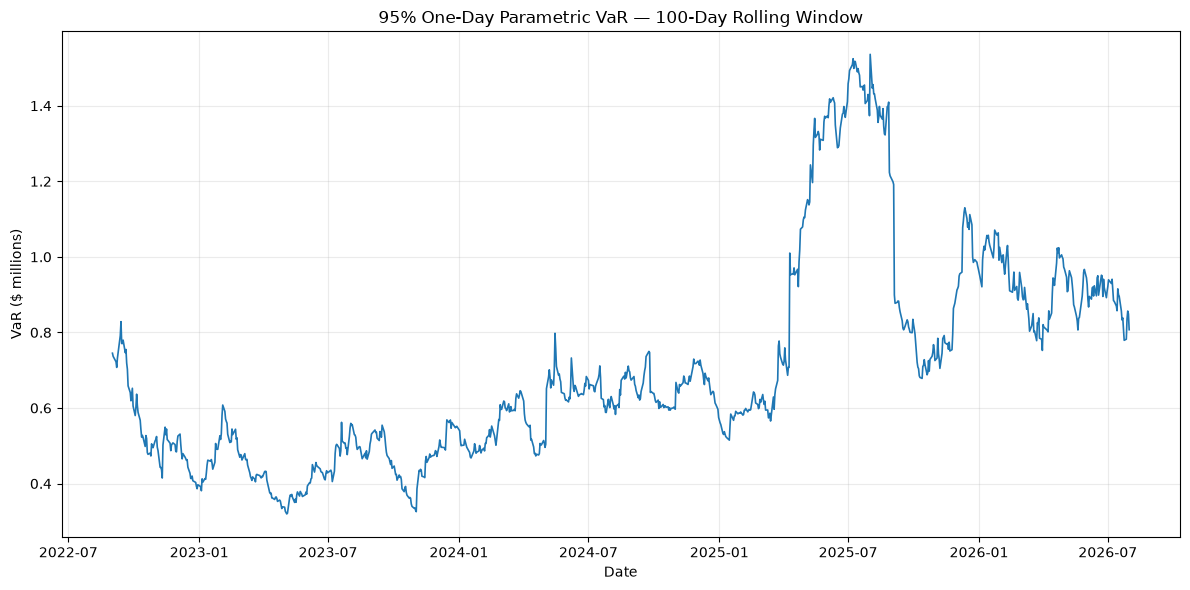

Saved figure: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q02_parametric_var.png


In [20]:
# ============================================================
# QUESTION 2A — PARAMETRIC VaR
# Variance-Covariance Method
# 100-Day Rolling Window
# ============================================================

print("=" * 70)
print("QUESTION 2A — PARAMETRIC VaR")
print("=" * 70)


# ------------------------------------------------------------
# 1. Confirm clean price data
# ------------------------------------------------------------

prices_q2 = prices[TICKERS].copy()
prices_q2 = prices_q2.dropna()

print("Clean price-data shape:", prices_q2.shape)
print("First date:", prices_q2.index.min().date())
print("Last date :", prices_q2.index.max().date())


# ------------------------------------------------------------
# 2. Determine initial shares on August 31, 2022
# ------------------------------------------------------------

FORMATION_DATE = pd.Timestamp("2022-08-31")

if FORMATION_DATE not in prices_q2.index:
    raise ValueError(
        f"{FORMATION_DATE.date()} is not available in the price data."
    )

initial_prices = prices_q2.loc[FORMATION_DATE]

initial_dollar_allocations = weights * PORTFOLIO_VALUE

# Fractional shares are allowed for the analytical portfolio.
shares = initial_dollar_allocations / initial_prices

initial_holdings = pd.DataFrame({
    "ticker": TICKERS,
    "initial_price": initial_prices.reindex(TICKERS).values,
    "initial_weight": weights.reindex(TICKERS).values,
    "initial_allocation": initial_dollar_allocations.reindex(TICKERS).values,
    "shares": shares.reindex(TICKERS).values
})

print("\nInitial holdings on August 31, 2022:")
display(initial_holdings)

initial_holdings.to_csv(
    TABLES / "Q02_initial_holdings.csv",
    index=False
)

print(
    "Saved:",
    TABLES / "Q02_initial_holdings.csv"
)


# ------------------------------------------------------------
# 3. Daily market value of each position
# ------------------------------------------------------------

position_values = prices_q2.mul(
    shares,
    axis=1
)

portfolio_value = position_values.sum(axis=1)

# Because the portfolio is NOT rebalanced,
# the weights change as stock prices change.
daily_weights = position_values.div(
    portfolio_value,
    axis=0
)


# ------------------------------------------------------------
# 4. Daily stock returns
# ------------------------------------------------------------

returns_q2 = prices_q2.pct_change(
    fill_method=None
).dropna()

print("\nDaily return data:")
display(returns_q2.head())


# ------------------------------------------------------------
# 5. Forecast dates
# ------------------------------------------------------------

FORECAST_START = pd.Timestamp("2022-09-01")
FORECAST_END = pd.Timestamp("2026-08-01")
WINDOW = 100
Z_95 = stats.norm.ppf(0.95)

forecast_dates = returns_q2.loc[
    FORECAST_START:FORECAST_END
].index

print("\nNumber of VaR forecast dates:", len(forecast_dates))


# ------------------------------------------------------------
# 6. Rolling 100-day parametric VaR
# ------------------------------------------------------------

parametric_results = []

for forecast_date in forecast_dates:

    # Position of forecast date in return data
    loc = returns_q2.index.get_loc(forecast_date)

    # Need exactly 100 PRIOR observations
    if loc < WINDOW:
        continue

    estimation_window = returns_q2.iloc[
        loc - WINDOW:loc
    ]

    # Covariance matrix based only on information
    # available before the forecast date
    cov_matrix = estimation_window.cov()

    # Previous trading day
    previous_date = returns_q2.index[loc - 1]

    # Portfolio weights at the end of t-1
    w_t = daily_weights.loc[
        previous_date,
        TICKERS
    ].values

    # Portfolio value at the end of t-1
    V_t = portfolio_value.loc[previous_date]

    # Conditional portfolio volatility
    portfolio_sigma = np.sqrt(
        w_t @ cov_matrix.values @ w_t
    )

    # 95% one-day parametric VaR
    var_return = Z_95 * portfolio_sigma

    var_dollar = var_return * V_t

    parametric_results.append({
        "date": forecast_date,
        "previous_date": previous_date,
        "portfolio_value": V_t,
        "portfolio_volatility": portfolio_sigma,
        "parametric_var_return": var_return,
        "parametric_var_dollar": var_dollar
    })


parametric_var = pd.DataFrame(
    parametric_results
).set_index("date")


# ------------------------------------------------------------
# 7. Inspect results
# ------------------------------------------------------------

print("\nParametric VaR results:")
display(parametric_var.head())

print("\nSummary statistics:")
display(
    parametric_var[
        [
            "portfolio_volatility",
            "parametric_var_return",
            "parametric_var_dollar"
        ]
    ].describe()
)


# ------------------------------------------------------------
# 8. Save full results
# ------------------------------------------------------------

parametric_var.to_csv(
    DATA_PROCESSED / "Q02_parametric_var.csv"
)

print(
    "\nSaved:",
    DATA_PROCESSED / "Q02_parametric_var.csv"
)


# ------------------------------------------------------------
# 9. Save summary table
# ------------------------------------------------------------

parametric_summary = (
    parametric_var[
        [
            "portfolio_volatility",
            "parametric_var_return",
            "parametric_var_dollar"
        ]
    ]
    .describe()
    .T
)

parametric_summary.to_csv(
    TABLES / "Q02_parametric_var_summary.csv"
)

print(
    "Saved:",
    TABLES / "Q02_parametric_var_summary.csv"
)


# ------------------------------------------------------------
# 10. Plot parametric VaR
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    parametric_var.index,
    parametric_var["parametric_var_dollar"] / 1_000_000,
    linewidth=1.2
)

ax.set_title(
    "95% One-Day Parametric VaR — 100-Day Rolling Window"
)

ax.set_xlabel("Date")
ax.set_ylabel("VaR ($ millions)")

ax.grid(alpha=0.25)

plt.tight_layout()

figure_path = (
    FIGURES / "Q02_parametric_var.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:", figure_path)

## 2B. One-factor model

Estimate a one-factor model and produce the requested \(\hat{\beta}\) forecast series.

We will define the exact factor specification before implementation and save the figure as:

```text
results/figures/Q02_factor_beta.png
```

### Question 2B — Code Process
1. Define the market factor
Use SPY as the proxy for the market factor in the one-factor model.
2. Download market-factor prices
Download historical SPY prices over the same sample period used for the portfolio so the market and portfolio returns can be aligned correctly.
3. Calculate market returns
Convert SPY prices into daily simple returns:
$$ r_{m,t} = \frac{P_{m,t}}{P_{m,t-1}}-1. $$
These daily returns represent the market factor.
4. Calculate portfolio returns
Because the portfolio is held without rebalancing, portfolio returns are calculated from the change in the total portfolio value:
$$ r_{p,t} = \frac{V_t}{V_{t-1}}-1. $$
This preserves the effect of changing portfolio weights over time.
5. Align portfolio and market returns
Combine the portfolio-return series and the SPY-return series and keep only dates for which both are available. This ensures that each regression uses matched observations.
6. Define the rolling forecast dates
Restrict the beta forecasts to the assignment period beginning September 1, 2022. A 100-trading-day rolling window is used so that the one-factor model is estimated using the same type of rolling structure as the parametric VaR analysis.
7. Estimate the rolling one-factor model
For each forecast date, use only the previous 100 trading days to estimate
$$ r_{p,s} = \alpha_t + \beta_t r_{m,s} + \epsilon_s, $$
where \(r_{p,s}\) is the portfolio return and \(r_{m,s}\) is the SPY return.
The regression is estimated by OLS, and the code stores:
$$ \hat{\alpha}_t,\qquad \hat{\beta}_t, $$
as well as the standard errors, \(R^2\), and residual standard deviation.
The forecast date itself is excluded from the estimation window, which avoids look-ahead bias.
8. Inspect the rolling estimates
Display the first few regression estimates and summary statistics for the rolling beta, alpha, \(R^2\), and residual volatility. This helps verify that the model is behaving reasonably over time.
9. Save the full one-factor results
Save the complete rolling regression output to:
data/processed/Q02_one_factor_model.csv
This preserves the daily beta estimates and related regression statistics for later analysis.
10. Save the beta summary table
Save descriptive statistics for the main one-factor-model estimates to:
results/tables/Q02_beta_summary.csv
11. Plot the rolling beta
Plot the estimated portfolio beta,
$$ \hat{\beta}_t, $$
over time. A horizontal reference line at \(\beta=1\) is included to make it easier to see when the portfolio has greater or lower sensitivity to the market than the market itself.
12. Save the beta figure
Save the final rolling-beta plot to:
results/figures/Q02_factor_beta.png


QUESTION 2B — ONE-FACTOR MODEL
Market factor proxy: SPY

SPY price data:


Date
2020-06-01    280.152496
2020-06-02    282.472260
2020-06-03    286.231415
2020-06-04    285.479492
2020-06-05    292.796234
Name: SPY, dtype: float64


SPY daily returns:


Date
2020-06-02    0.008280
2020-06-03    0.013308
2020-06-04   -0.002627
2020-06-05    0.025630
2020-06-08    0.012087
Name: market_return, dtype: float64


Portfolio daily returns:


...


Number of aligned observations:
1549

Number of beta forecast dates: 981

Rolling one-factor estimates:


,alpha_hat,beta_hat,alpha_se,beta_se,r_squared,residual_std
date,,,,,,
2022-09-01,-0.000718,2.125501,0.003008,0.185506,0.572581,0.030014
2022-09-02,-0.000859,2.123063,0.003011,0.185681,0.571557,0.030051
2022-09-06,-0.001195,2.147507,0.002977,0.184225,0.580992,0.029720
2022-09-07,-0.001227,2.147881,0.002979,0.184303,0.580870,0.029733
2022-09-08,-0.001432,2.137688,0.002974,0.183329,0.581133,0.029691



Beta summary statistics:


,beta_hat,alpha_hat,r_squared,residual_std
count,981.000000,981.000000,981.000000,981.000000
mean,1.827614,-0.000102,0.458879,0.018757
std,0.287520,0.001118,0.123794,0.002925
min,0.970358,-0.003653,0.185907,0.014036
25%,1.674662,-0.000754,0.380043,0.016860
50%,1.831341,-0.000151,0.426905,0.018151
75%,2.013834,0.000556,0.531871,0.019926
max,2.429154,0.002995,0.741281,0.030051



Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/processed/Q02_one_factor_model.csv
Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q02_beta_summary.csv


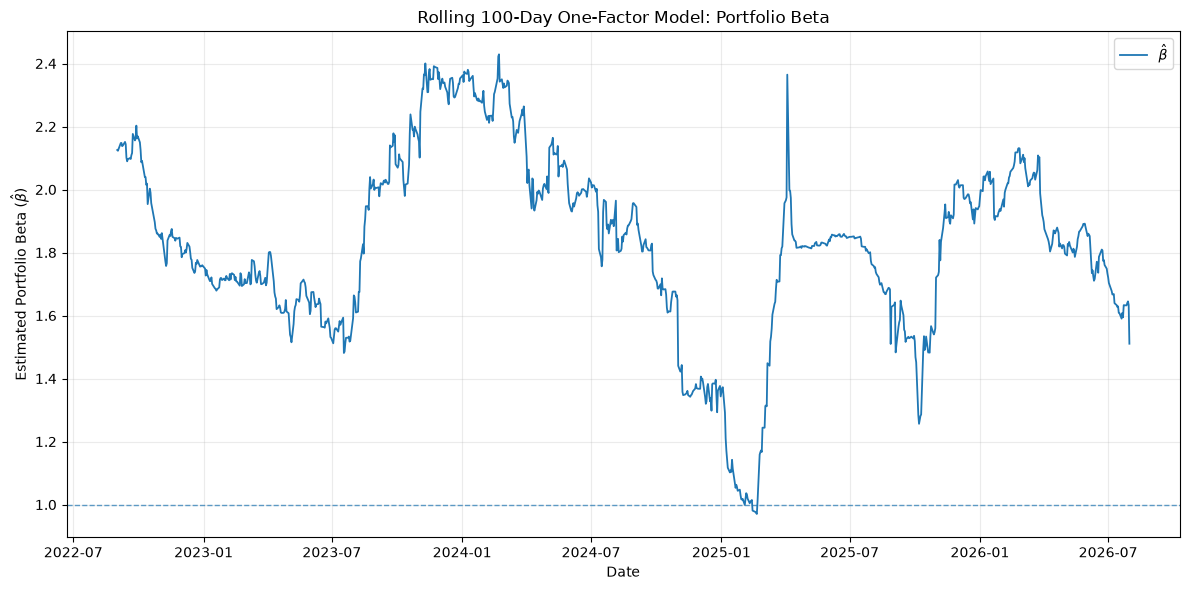

Saved figure: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q02_factor_beta.png


In [21]:
# ============================================================
# QUESTION 2B — ONE-FACTOR MODEL
# Rolling 100-Day Portfolio Beta
# Market Factor: SPY
# ============================================================

print("=" * 70)
print("QUESTION 2B — ONE-FACTOR MODEL")
print("=" * 70)


# ------------------------------------------------------------
# 1. Define the market factor
# ------------------------------------------------------------

MARKET_TICKER = "SPY"

print(f"Market factor proxy: {MARKET_TICKER}")


# ------------------------------------------------------------
# 2. Download market-factor prices
# ------------------------------------------------------------

spy_raw = yf.download(
    MARKET_TICKER,
    start=DOWNLOAD_START,
    end=DOWNLOAD_END,
    auto_adjust=True,
    progress=False
)

# Handle yfinance output format
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_price = spy_raw["Close"].iloc[:, 0].copy()
else:
    spy_price = spy_raw["Close"].copy()

spy_price.name = "SPY"

print("\nSPY price data:")
display(spy_price.head())


# ------------------------------------------------------------
# 3. Calculate market returns
# ------------------------------------------------------------

spy_returns = spy_price.pct_change(
    fill_method=None
).dropna()

spy_returns.name = "market_return"

print("\nSPY daily returns:")
display(spy_returns.head())


# ------------------------------------------------------------
# 4. Calculate actual portfolio returns
# ------------------------------------------------------------

# Since shares are fixed and the portfolio is not rebalanced,
# portfolio returns are calculated directly from the change
# in total portfolio value.

portfolio_returns = portfolio_value.pct_change(
    fill_method=None
).dropna()

portfolio_returns.name = "portfolio_return"

print("\nPortfolio daily returns:")
display(portfolio_returns.head())


# ------------------------------------------------------------
# 5. Align portfolio and market returns
# ------------------------------------------------------------

factor_data = pd.concat(
    [
        portfolio_returns,
        spy_returns
    ],
    axis=1,
    join="inner"
).dropna()

print("\nAligned portfolio and market-return data:")
display(factor_data.head())

print("\nNumber of aligned observations:")
print(len(factor_data))


# ------------------------------------------------------------
# 6. Define rolling forecast dates
# ------------------------------------------------------------

BETA_WINDOW = 100

beta_forecast_dates = factor_data.loc[
    FORECAST_START:FORECAST_END
].index

print(
    "\nNumber of beta forecast dates:",
    len(beta_forecast_dates)
)


# ------------------------------------------------------------
# 7. Estimate rolling 100-day one-factor model
# ------------------------------------------------------------

beta_results = []

for forecast_date in beta_forecast_dates:

    loc = factor_data.index.get_loc(
        forecast_date
    )

    # Need 100 observations before forecast date
    if loc < BETA_WINDOW:
        continue

    estimation_window = factor_data.iloc[
        loc - BETA_WINDOW:loc
    ]

    # Dependent variable:
    # portfolio return
    y = estimation_window[
        "portfolio_return"
    ]

    # Independent variable:
    # market return
    X = estimation_window[
        ["market_return"]
    ]

    # Add intercept alpha
    X = sm.add_constant(X)

    # Estimate OLS one-factor model
    model = sm.OLS(
        y,
        X
    ).fit()

    alpha_hat = model.params["const"]
    beta_hat = model.params["market_return"]

    alpha_se = model.bse["const"]
    beta_se = model.bse["market_return"]

    r_squared = model.rsquared

    residual_std = np.sqrt(
        model.mse_resid
    )

    beta_results.append({
        "date": forecast_date,
        "alpha_hat": alpha_hat,
        "beta_hat": beta_hat,
        "alpha_se": alpha_se,
        "beta_se": beta_se,
        "r_squared": r_squared,
        "residual_std": residual_std
    })


# Convert results to DataFrame
beta_forecasts = pd.DataFrame(
    beta_results
).set_index("date")


# ------------------------------------------------------------
# 8. Inspect beta forecasts
# ------------------------------------------------------------

print("\nRolling one-factor estimates:")
display(beta_forecasts.head())

print("\nBeta summary statistics:")
display(
    beta_forecasts[
        [
            "beta_hat",
            "alpha_hat",
            "r_squared",
            "residual_std"
        ]
    ].describe()
)


# ------------------------------------------------------------
# 9. Save full one-factor results
# ------------------------------------------------------------

beta_forecasts.to_csv(
    DATA_PROCESSED /
    "Q02_one_factor_model.csv"
)

print(
    "\nSaved:",
    DATA_PROCESSED /
    "Q02_one_factor_model.csv"
)


# ------------------------------------------------------------
# 10. Save beta summary table
# ------------------------------------------------------------

beta_summary = (
    beta_forecasts[
        [
            "beta_hat",
            "alpha_hat",
            "r_squared",
            "residual_std"
        ]
    ]
    .describe()
    .T
)

beta_summary.to_csv(
    TABLES /
    "Q02_beta_summary.csv"
)

print(
    "Saved:",
    TABLES /
    "Q02_beta_summary.csv"
)


# ------------------------------------------------------------
# 11. Plot rolling beta forecasts
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    beta_forecasts.index,
    beta_forecasts["beta_hat"],
    linewidth=1.3,
    label=r"$\hat{\beta}$"
)

# Reference line: beta = 1
ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

ax.set_title(
    "Rolling 100-Day One-Factor Model: "
    "Portfolio Beta"
)

ax.set_xlabel("Date")
ax.set_ylabel(
    r"Estimated Portfolio Beta ($\hat{\beta}$)"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()


# ------------------------------------------------------------
# 12. Save figure
# ------------------------------------------------------------

beta_figure_path = (
    FIGURES /
    "Q02_factor_beta.png"
)

plt.savefig(
    beta_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    beta_figure_path
)

## q 2 — Results and Discussion
### 2A. Parametric VaR
Using a 100-trading-day rolling variance-covariance matrix, I generated 981 one-day 95% parametric VaR forecasts over the required forecast period. The portfolio was formed on August 31, 2022 with an initial value of $10$ million. Because the portfolio is held without rebalancing, the number of shares remains fixed while both portfolio value and portfolio weights evolve over time. This follows the assignment requirement to forecast VaR using a rolling 100-day covariance matrix.
For the first forecast on September 1, 2022, the estimated daily portfolio volatility was
$$ \sigma_{p,t}=0.045295, $$
or approximately 4.53%. Using the one-sided 95% normal critical value \(z_{0.95}=1.644854\), the corresponding VaR was
$$ VaR_{95\%} = 1.644854(0.045295) = 0.074504. $$
Thus, the estimated one-day VaR was approximately 7.45% of portfolio value, corresponding to a dollar VaR of approximately
$$ {\$745{,}042}. $$
Across the full forecast period, the average estimated portfolio volatility was approximately 2.69% per day, while the average 95% parametric VaR was approximately 4.42% of portfolio value. The average dollar VaR was approximately
$$ {\$702{,}578}. $$
The dollar VaR ranged from approximately $319,556 to $1.536 million, indicating substantial variation in portfolio risk over time. Higher VaR values correspond to periods in which the recent 100-day covariance matrix indicates elevated volatility and/or when the market value of the portfolio is higher. The time variation in the VaR series therefore reflects both changing market conditions and the changing composition of the buy-and-hold portfolio.


### 2B. One-Factor Model
A one-factor market model is estimated using SPY returns as the market factor:
$$ r_{p,t} = \alpha_t + \beta_t r_{m,t} + \epsilon_t. $$
For every forecast date, the model is estimated using only the preceding 100 trading days, producing a rolling estimate of the portfolio's market sensitivity, \(\hat{\beta}_t\). The forecast date itself is excluded from the estimation sample so that the procedure does not introduce look-ahead bias.
The rolling beta measures how sensitive the portfolio is to movements in the broader equity market. A value of
$$ \hat{\beta}=1 $$
indicates approximately the same systematic sensitivity as the market. Values above one indicate greater sensitivity to market movements, while values below one indicate lower market sensitivity.
Because this portfolio contains stocks such as GME, ROKU, DKNG, CVNA, and W, its risk is not driven solely by broad-market movements. The rolling one-factor model allows the portfolio's systematic exposure to be separated from firm-specific or idiosyncratic variation. Changes in \(\hat{\beta}\) through time indicate that the portfolio's exposure to market risk is not constant, which is consistent with the fact that the portfolio is held without rebalancing and therefore its individual stock weights evolve as prices change.
The rolling beta figure provides a useful complement to the parametric VaR results. Parametric VaR measures the portfolio's total short-horizon risk, incorporating variances and covariances across all ten stocks, whereas \(\hat{\beta}\) measures specifically the portfolio's exposure to the common market factor. Therefore, periods of high VaR do not necessarily have to coincide with periods of high beta; VaR can also increase because of higher idiosyncratic volatility or stronger correlations among the individual portfolio stocks.

# 3. Non-parametric VaR using historical simulation

Using a rolling **100-day window**, forecast the 95% one-day historical-simulation VaR.

For each date, use the empirical lower tail of the preceding 100 portfolio returns.


Historical simulation estimates VaR directly from the empirical distribution of past returns and therefore does not require the normal-distribution assumption used in Question 2A.
For each forecast date \(t\), the code uses the previous 100 trading days of stock returns as historical scenarios. Because the portfolio is not rebalanced, the portfolio weights at the end of the previous trading day, \(w_{t-1}\), are used to revalue the current portfolio under each of these historical return scenarios.
For historical scenario \(s\),
$$ r_{p,s}^{(t)} = w_{t-1}^{\top}r_s, $$
where \(r_s\) is the vector of stock returns observed on historical day \(s\).
The 95% historical-simulation VaR return is then the negative of the empirical 5th percentile:
$$ VaR_{t,95\%}^{HS} = - Q_{0.05} \left( r_{p,s}^{(t)} \right). $$
Dollar VaR is obtained by multiplying the return VaR by the portfolio value at the end of the previous trading day:
$$ VaR_{t,95\%}^{HS,\$} = VaR_{t,95\%}^{HS} V_{t-1}. $$
The 100-day estimation window moves forward one trading day at a time.


### q 3 — Code Process
1. Set the historical-simulation parameters
The code sets the rolling estimation window to 100 trading days and the confidence level to 95%. Therefore, the relevant lower-tail probability is 5%.
2. Prepare the stock-return data
The daily returns of the ten portfolio stocks from the earlier steps are selected and organized into one return matrix. These returns are the historical scenarios used to estimate non-parametric VaR.
3. Define the forecast dates
The code restricts the forecast period to the dates required by the assignment, beginning on September 1, 2022. A VaR estimate is generated for each trading day in the forecast period.
4. Construct the rolling 100-day historical window
For each forecast date \(t\), the code selects exactly the previous 100 trading days of stock returns:
$$ r_{t-100},\ldots,r_{t-1}. $$
The forecast date itself is excluded, so only information available before the forecast is used.
5. Use the current portfolio weights
Because the portfolio is not rebalanced, the code uses the portfolio weights observed at the end of the previous trading day, \(w_{t-1}\). These weights reflect the changing market values of the fixed stock holdings.
6. Generate historical portfolio-return scenarios
The current portfolio weights are applied to each of the 100 historical stock-return vectors:
$$ r_{p,s}^{(t)} = w_{t-1}^{\top}r_s. $$
This produces 100 hypothetical portfolio returns based on the historical return distribution.
7. Calculate the 95% historical VaR
The code calculates the empirical 5th percentile of the 100 simulated portfolio returns. Because VaR is reported as a positive loss magnitude,
$$ VaR_{t,95\%}^{HS} = - Q_{0.05}(r_p). $$
8. Convert VaR to dollar terms
The VaR return is multiplied by the portfolio value at the end of the previous trading day:
$$ VaR_{t,95\%}^{HS,\$} = VaR_{t,95\%}^{HS} \times V_{t-1}. $$
9. Repeat the calculation for every forecast date
The 100-day window moves forward by one trading day at a time, producing a complete rolling historical-simulation VaR series.
10. Inspect the results
The code displays the first several VaR estimates and descriptive statistics to check the level and variation of the forecasts.
11. Save the daily VaR results
The full historical-simulation VaR series is saved to:
data/processed/Q03_historical_var_100.csv
12. Save the summary table
Descriptive statistics are saved to:
results/tables/Q03_historical_var_100_summary.csv
13. Plot and save the VaR series
The 95% one-day historical VaR is plotted over time and saved to:
results/figures/Q03_historical_var_100.png


QUESTION 3 — HISTORICAL SIMULATION VaR
Rolling window       : 100 trading days
Confidence level     : 95%
Lower-tail percentile: 5%

Stock-return data:
First date: 2020-06-02
Last date : 2026-07-31
Shape     : (1549, 10)

Number of historical-simulation forecast dates: 981

Historical-simulation VaR results:


,previous_date,portfolio_value,historical_var_return_100,historical_var_dollar_100,historical_quantile_5pct
date,,,,,
2022-09-01,2022-08-31,1.000000e+07,0.071391,713906.919756,-0.071391
2022-09-02,2022-09-01,9.910863e+06,0.071336,707004.927122,-0.071336
2022-09-06,2022-09-02,9.765569e+06,0.071052,693863.543129,-0.071052
2022-09-07,2022-09-06,9.545856e+06,0.071534,682853.432377,-0.071534
2022-09-08,2022-09-07,9.866089e+06,0.071971,710070.731232,-0.071971



Summary statistics:


,historical_var_return_100,historical_var_dollar_100
count,981.000000,9.810000e+02
mean,0.039819,6.349235e+05
std,0.011100,2.717172e+05
min,0.016589,2.698021e+05
25%,0.032838,4.398847e+05
50%,0.036931,5.287535e+05
75%,0.046591,8.248528e+05
max,0.072729,1.460476e+06



Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/processed/Q03_historical_var_100.csv
Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q03_historical_var_100_summary.csv


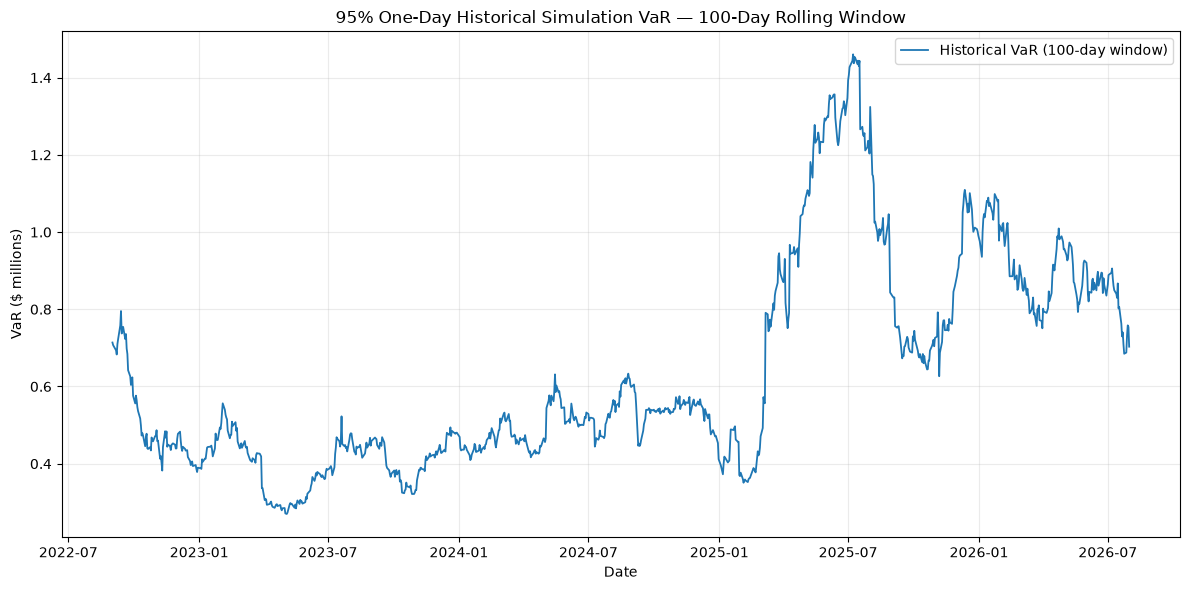

Saved figure: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q03_historical_var_100.png


In [22]:
# ============================================================
# QUESTION 3 — HISTORICAL SIMULATION VaR
# 95% One-Day VaR
# 100-Day Rolling Window
# ============================================================

print("=" * 70)
print("QUESTION 3 — HISTORICAL SIMULATION VaR")
print("=" * 70)


# ------------------------------------------------------------
# 1. Set historical-simulation parameters
# ------------------------------------------------------------

HS_WINDOW = 100
HS_CONFIDENCE = 0.95
HS_ALPHA = 1 - HS_CONFIDENCE

print(f"Rolling window       : {HS_WINDOW} trading days")
print(f"Confidence level     : {HS_CONFIDENCE:.0%}")
print(f"Lower-tail percentile: {HS_ALPHA:.0%}")


# ------------------------------------------------------------
# 2. Use the stock returns from Question 2
# ------------------------------------------------------------

hs_returns = returns_q2[TICKERS].copy()

print("\nStock-return data:")
print("First date:", hs_returns.index.min().date())
print("Last date :", hs_returns.index.max().date())
print("Shape     :", hs_returns.shape)


# ------------------------------------------------------------
# 3. Define forecast dates
# ------------------------------------------------------------

hs_forecast_dates = hs_returns.loc[
    FORECAST_START:FORECAST_END
].index

print(
    "\nNumber of historical-simulation forecast dates:",
    len(hs_forecast_dates)
)


# ------------------------------------------------------------
# 4. Calculate rolling 100-day historical VaR
# ------------------------------------------------------------

historical_results = []

for forecast_date in hs_forecast_dates:

    loc = hs_returns.index.get_loc(
        forecast_date
    )

    # Need exactly 100 observations BEFORE forecast date
    if loc < HS_WINDOW:
        continue

    # Historical return scenarios
    estimation_window = hs_returns.iloc[
        loc - HS_WINDOW:loc
    ]

    # Previous trading day
    previous_date = hs_returns.index[
        loc - 1
    ]

    # Current portfolio weights at t-1
    w_t = daily_weights.loc[
        previous_date,
        TICKERS
    ].values

    # Portfolio value at t-1
    V_t = portfolio_value.loc[
        previous_date
    ]

    # --------------------------------------------------------
    # Apply current portfolio weights to each historical
    # stock-return scenario
    # --------------------------------------------------------

    historical_portfolio_returns = (
        estimation_window.values @ w_t
    )

    # --------------------------------------------------------
    # Empirical 5th percentile
    # --------------------------------------------------------

    lower_tail_quantile = np.quantile(
        historical_portfolio_returns,
        HS_ALPHA
    )

    # Report VaR as a positive loss magnitude
    historical_var_return = (
        -lower_tail_quantile
    )

    historical_var_dollar = (
        historical_var_return * V_t
    )

    historical_results.append({
        "date": forecast_date,
        "previous_date": previous_date,
        "portfolio_value": V_t,
        "historical_var_return_100":
            historical_var_return,
        "historical_var_dollar_100":
            historical_var_dollar,
        "historical_quantile_5pct":
            lower_tail_quantile
    })


# Convert to DataFrame
historical_var_100 = pd.DataFrame(
    historical_results
).set_index("date")


# ------------------------------------------------------------
# 5. Inspect results
# ------------------------------------------------------------

print("\nHistorical-simulation VaR results:")
display(
    historical_var_100.head()
)

print("\nSummary statistics:")

historical_summary_100 = (
    historical_var_100[
        [
            "historical_var_return_100",
            "historical_var_dollar_100"
        ]
    ]
    .describe()
)

display(
    historical_summary_100
)


# ------------------------------------------------------------
# 6. Save full results
# ------------------------------------------------------------

historical_var_100.to_csv(
    DATA_PROCESSED /
    "Q03_historical_var_100.csv"
)

print(
    "\nSaved:",
    DATA_PROCESSED /
    "Q03_historical_var_100.csv"
)


# ------------------------------------------------------------
# 7. Save summary table
# ------------------------------------------------------------

historical_summary_100.T.to_csv(
    TABLES /
    "Q03_historical_var_100_summary.csv"
)

print(
    "Saved:",
    TABLES /
    "Q03_historical_var_100_summary.csv"
)


# ------------------------------------------------------------
# 8. Plot 100-day historical-simulation VaR
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    historical_var_100.index,
    historical_var_100[
        "historical_var_dollar_100"
    ] / 1_000_000,
    linewidth=1.3,
    label="Historical VaR (100-day window)"
)

ax.set_title(
    "95% One-Day Historical Simulation VaR "
    "— 100-Day Rolling Window"
)

ax.set_xlabel("Date")
ax.set_ylabel("VaR ($ millions)")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()


# ------------------------------------------------------------
# 9. Save figure
# ------------------------------------------------------------

historical_figure_path = (
    FIGURES /
    "Q03_historical_var_100.png"
)

plt.savefig(
    historical_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    historical_figure_path
)

## Results and Interpretation for q3
Using a 100-trading-day rolling historical-simulation method, I generated 981 one-day 95% VaR forecasts over the required forecast period. The method uses the empirical distribution of the previous 100 daily return scenarios rather than assuming that returns follow a normal distribution, as in the parametric approach. This follows the assignment requirement for a 95% one-day historical-simulation VaR using a rolling 100-day window.
For the first forecast date, September 1, 2022, the estimated 5th percentile of the historical portfolio-return distribution was
$$ Q_{0.05}=-0.071391. $$
Therefore, the 95% historical-simulation VaR was
$$ VaR_{95\%}^{HS} = -(-0.071391) = 0.071391, $$
or approximately 7.14% of portfolio value. With a portfolio value of $10$ million, the corresponding dollar VaR was
$$ {\$713{,}907}. $$
Across all 981 forecasts, the average historical-simulation VaR was approximately
$$ {3.98\%} $$
of portfolio value, corresponding to an average dollar VaR of approximately
$$ {\$634{,}924}. $$
The median dollar VaR was approximately $528,754$, while the forecasts ranged from approximately $269,802 to $1.460 million.
The results show substantial time variation in portfolio risk. Because historical simulation uses the actual empirical returns observed during the preceding 100 trading days, the VaR tends to increase when large negative returns enter the rolling window and decline when those extreme observations eventually leave the window. As a result, the historical VaR series can exhibit relatively sharp changes and persistent high-risk periods following episodes of market stress.
Comparison with Parametric VaR
The historical-simulation estimates are somewhat lower on average than the parametric VaR estimates from Question 2A:

| Measure | Parametric VaR | Historical VaR |
|---|---:|---:|
| Mean VaR return | 4.42% | 3.98% |
| Mean dollar VaR | \$702,578 | \$634,924 |
| Maximum dollar VaR | \$1.536M | \$1.460M |
| Sep. 1, 2022 VaR | \$745,042 | \$713,907 |

Thus, in this sample, the normal variance-covariance method generally produces a somewhat more conservative risk estimate than the 100-day historical-simulation method. However, historical simulation has the advantage of incorporating the empirical shape of the return distribution directly, including asymmetry and extreme observations, without imposing a normal-distribution assumption.

# 4. Marginal VaR

Forecast the 95% one-day **marginal VaR** for:

- GME
- one other stock in the final portfolio

We will use a consistent portfolio-VaR convention and clearly state whether marginal VaR is reported per unit of portfolio weight or for a specified weight change.

## Q 4 — Code Process
Add this as a Markdown cell before the code.
1. Select the two stocks
Calculate marginal VaR for GME and DKS.
2. Use the 100-day historical window
For each forecast date, use the same previous 100 daily stock-return observations used in Question 3.
3. Use current portfolio weights
Because the portfolio is not rebalanced, use the portfolio weights observed at the end of the previous trading day.
4. Calculate the base historical VaR
Apply the current portfolio weights to the 100 historical return scenarios and calculate the empirical 5th percentile:
$$ VaR_t=-Q_{0.05}(r_{p,t}). $$
5. Perturb one stock's weight
To measure marginal risk, increase the target stock's portfolio weight by a small amount,
$$ \Delta w=0.01, $$
corresponding to a 1 percentage-point increase. The weights of the remaining stocks are reduced proportionally so that total portfolio weight remains equal to 100%.
6. Recalculate VaR
Using the perturbed portfolio weights, recalculate historical-simulation VaR.
7. Calculate marginal VaR
Marginal VaR is approximated using the finite-difference sensitivity:
$$ MVaR_i \approx \frac{ VaR(w+\Delta w_i)-VaR(w) }{ \Delta w }. $$
For easier interpretation, the code also reports the dollar change in VaR associated with a 1 percentage-point increase in the stock's portfolio weight.
8. Repeat over all forecast dates
Repeat the procedure for every trading day in the forecast period for both GME and DKS.
9. Save results and plot
Save the full marginal-VaR series, summary statistics, and a figure comparing GME and DKS.

QUESTION 4 — MARGINAL VaR
Stocks: ['GME', 'DKS']
Rolling window: 100
Confidence level: 95%
Weight perturbation: 1.0%

Number of marginal VaR forecast dates: 981

Marginal VaR results:


,marginal_var_GME,marginal_var_DKS,var_change_1pct_dollar_GME,var_change_1pct_dollar_DKS
date,,,,
2022-09-01,-0.025745,-0.033413,-2574.514499,-3341.277909
2022-09-02,-0.045399,-0.033472,-4499.406052,-3317.358257
2022-09-06,-0.045108,-0.033191,-4405.040432,-3241.295864
2022-09-07,-0.045347,-0.033728,-4328.772483,-3219.643233
2022-09-08,-0.045484,-0.034290,-4487.462261,-3383.107769



Summary statistics:


,marginal_var_GME,marginal_var_DKS,var_change_1pct_dollar_GME,var_change_1pct_dollar_DKS
count,981.000000,981.000000,981.000000,981.000000
mean,-0.007922,-0.024537,-2194.699058,-4122.104844
std,0.033894,0.016392,6285.472424,3497.369858
min,-0.168789,-0.070063,-38471.480102,-15600.606807
25%,-0.030066,-0.038251,-6318.591251,-5696.927038
50%,-0.011466,-0.021069,-1543.502901,-3237.525212
75%,0.014707,-0.014876,1705.563000,-1844.210468
max,0.175843,0.030372,43317.083808,5307.404214



Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/processed/Q04_marginal_var_100.csv
Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q04_marginal_var_100_summary.csv


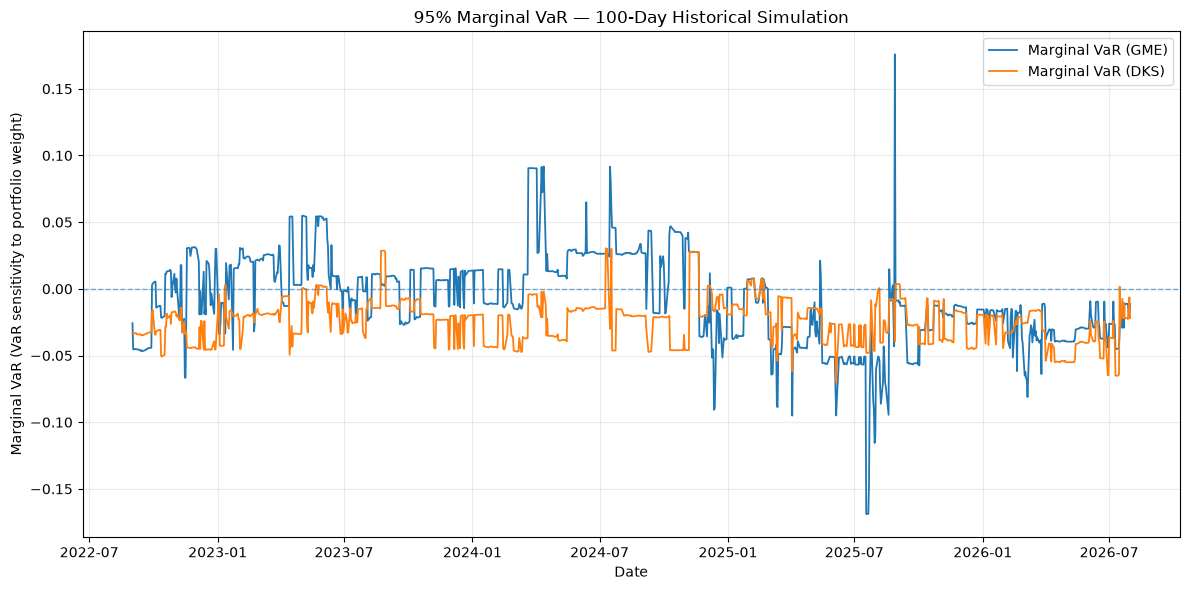

Saved figure: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q04_marginal_var_100.png


In [23]:
# ============================================================
# QUESTION 4 — MARGINAL VaR
# Historical Simulation
# 100-Day Rolling Window
# Stocks: GME and DKS
# ============================================================

print("=" * 70)
print("QUESTION 4 — MARGINAL VaR")
print("=" * 70)


# ------------------------------------------------------------
# 1. Select stocks and parameters
# ------------------------------------------------------------

MARGINAL_STOCKS = ["GME", "DKS"]

MVAR_WINDOW = 100
MVAR_CONFIDENCE = 0.95
MVAR_ALPHA = 1 - MVAR_CONFIDENCE

# Increase target weight by 1 percentage point
DELTA_WEIGHT = 0.01

print("Stocks:", MARGINAL_STOCKS)
print("Rolling window:", MVAR_WINDOW)
print("Confidence level:", f"{MVAR_CONFIDENCE:.0%}")
print("Weight perturbation:", f"{DELTA_WEIGHT:.1%}")


# ------------------------------------------------------------
# 2. Function to increase one stock's weight
#    while keeping total portfolio weight equal to 1
# ------------------------------------------------------------

def perturb_weight(weights_vector, target_index, delta=0.01):
    """
    Increase one asset's weight by delta and reduce all other
    weights proportionally so that the portfolio still sums to 1.
    """

    w_new = np.array(
        weights_vector,
        dtype=float
    ).copy()

    old_target_weight = w_new[target_index]
    new_target_weight = old_target_weight + delta

    if new_target_weight >= 1:
        raise ValueError(
            "Perturbed target weight must remain below 100%."
        )

    # Total weight initially allocated to other stocks
    old_other_weight = 1 - old_target_weight

    # Remaining weight after increasing target stock
    new_other_weight = 1 - new_target_weight

    # Scale all other stocks proportionally
    scale = new_other_weight / old_other_weight

    for j in range(len(w_new)):
        if j != target_index:
            w_new[j] *= scale

    w_new[target_index] = new_target_weight

    # Numerical check
    assert np.isclose(
        w_new.sum(),
        1.0
    )

    return w_new


# ------------------------------------------------------------
# 3. Prepare return data
# ------------------------------------------------------------

mvar_returns = returns_q2[
    TICKERS
].copy()

mvar_forecast_dates = mvar_returns.loc[
    FORECAST_START:FORECAST_END
].index

print(
    "\nNumber of marginal VaR forecast dates:",
    len(mvar_forecast_dates)
)


# ------------------------------------------------------------
# 4. Rolling marginal VaR calculation
# ------------------------------------------------------------

mvar_results = []

for forecast_date in mvar_forecast_dates:

    loc = mvar_returns.index.get_loc(
        forecast_date
    )

    # Need 100 observations before forecast date
    if loc < MVAR_WINDOW:
        continue

    # Previous 100 historical return scenarios
    estimation_window = mvar_returns.iloc[
        loc - MVAR_WINDOW:loc
    ]

    previous_date = mvar_returns.index[
        loc - 1
    ]

    # Current portfolio weights at t-1
    current_weights = daily_weights.loc[
        previous_date,
        TICKERS
    ].values

    # Current portfolio value at t-1
    current_portfolio_value = portfolio_value.loc[
        previous_date
    ]

    # --------------------------------------------------------
    # Base historical-simulation VaR
    # --------------------------------------------------------

    base_scenario_returns = (
        estimation_window.values
        @ current_weights
    )

    base_quantile = np.quantile(
        base_scenario_returns,
        MVAR_ALPHA
    )

    base_var_return = -base_quantile

    base_var_dollar = (
        base_var_return
        * current_portfolio_value
    )

    result = {
        "date": forecast_date,
        "previous_date": previous_date,
        "portfolio_value":
            current_portfolio_value,
        "base_var_return":
            base_var_return,
        "base_var_dollar":
            base_var_dollar
    }

    # --------------------------------------------------------
    # 5. Marginal VaR for GME and DKS
    # --------------------------------------------------------

    for ticker in MARGINAL_STOCKS:

        target_index = TICKERS.index(
            ticker
        )

        # Increase target stock weight by 1 percentage point
        perturbed_weights = perturb_weight(
            current_weights,
            target_index,
            DELTA_WEIGHT
        )

        # Historical portfolio returns using
        # perturbed weights
        perturbed_returns = (
            estimation_window.values
            @ perturbed_weights
        )

        perturbed_quantile = np.quantile(
            perturbed_returns,
            MVAR_ALPHA
        )

        perturbed_var_return = (
            -perturbed_quantile
        )

        # ----------------------------------------------------
        # Finite-difference marginal VaR
        # ----------------------------------------------------

        marginal_var_return = (
            perturbed_var_return
            - base_var_return
        ) / DELTA_WEIGHT

        marginal_var_dollar = (
            marginal_var_return
            * current_portfolio_value
        )

        # Actual change in VaR from a +1 percentage-point
        # increase in portfolio weight
        incremental_var_1pct = (
            perturbed_var_return
            - base_var_return
        )

        incremental_var_1pct_dollar = (
            incremental_var_1pct
            * current_portfolio_value
        )

        result[
            f"marginal_var_{ticker}"
        ] = marginal_var_return

        result[
            f"marginal_var_dollar_{ticker}"
        ] = marginal_var_dollar

        result[
            f"var_change_1pct_{ticker}"
        ] = incremental_var_1pct

        result[
            f"var_change_1pct_dollar_{ticker}"
        ] = incremental_var_1pct_dollar

    mvar_results.append(result)


# ------------------------------------------------------------
# 6. Convert results to DataFrame
# ------------------------------------------------------------

marginal_var_100 = pd.DataFrame(
    mvar_results
).set_index("date")


# ------------------------------------------------------------
# 7. Inspect results
# ------------------------------------------------------------

print("\nMarginal VaR results:")

display(
    marginal_var_100[
        [
            "marginal_var_GME",
            "marginal_var_DKS",
            "var_change_1pct_dollar_GME",
            "var_change_1pct_dollar_DKS"
        ]
    ].head()
)


# ------------------------------------------------------------
# 8. Summary statistics
# ------------------------------------------------------------

mvar_summary = (
    marginal_var_100[
        [
            "marginal_var_GME",
            "marginal_var_DKS",
            "var_change_1pct_dollar_GME",
            "var_change_1pct_dollar_DKS"
        ]
    ]
    .describe()
)

print("\nSummary statistics:")

display(
    mvar_summary
)


# ------------------------------------------------------------
# 9. Save full results
# ------------------------------------------------------------

marginal_var_100.to_csv(
    DATA_PROCESSED /
    "Q04_marginal_var_100.csv"
)

print(
    "\nSaved:",
    DATA_PROCESSED /
    "Q04_marginal_var_100.csv"
)


# ------------------------------------------------------------
# 10. Save summary table
# ------------------------------------------------------------

mvar_summary.T.to_csv(
    TABLES /
    "Q04_marginal_var_100_summary.csv"
)

print(
    "Saved:",
    TABLES /
    "Q04_marginal_var_100_summary.csv"
)


# ------------------------------------------------------------
# 11. Plot marginal VaR
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    marginal_var_100.index,
    marginal_var_100[
        "marginal_var_GME"
    ],
    linewidth=1.3,
    label="Marginal VaR (GME)"
)

ax.plot(
    marginal_var_100.index,
    marginal_var_100[
        "marginal_var_DKS"
    ],
    linewidth=1.3,
    label="Marginal VaR (DKS)"
)

# Reference line
ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_title(
    "95% Marginal VaR — "
    "100-Day Historical Simulation"
)

ax.set_xlabel("Date")

ax.set_ylabel(
    "Marginal VaR "
    "(VaR sensitivity to portfolio weight)"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()


# ------------------------------------------------------------
# 12. Save figure
# ------------------------------------------------------------

mvar_figure_path = (
    FIGURES /
    "Q04_marginal_var_100.png"
)

plt.savefig(
    mvar_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    mvar_figure_path
)

## Q 4 — Results and Interpretation
Using the 100-day rolling historical-simulation framework, I estimated the 95% one-day marginal VaR for GME and DKS, as required in the assignment. Marginal VaR is approximated by increasing the selected stock's portfolio weight by 1 percentage point, reducing the remaining weights proportionally, and measuring the resulting change in portfolio VaR.
For September 1, 2022, the estimated marginal VaR was
$$ MVaR_{GME}=-0.0257, $$
and
$$ MVaR_{DKS}=-0.0334. $$
A 1 percentage-point increase in GME's portfolio weight reduced the estimated dollar VaR by approximately
$$ {\$2{,}575}, $$
while the same increase in DKS reduced VaR by approximately
$$ {\$3{,}341}. $$
Across the full 981-day forecast period, the average marginal VaR was approximately −0.0079 for GME and −0.0245 for DKS. In dollar terms, a 1 percentage-point increase in weight was associated on average with a VaR change of approximately −$2,195$ for GME and −$4,122$ for DKS.
The marginal VaR estimates vary substantially over time. For GME, the marginal VaR ranges from approximately −0.169 to 0.176, while for DKS it ranges from approximately −0.070 to 0.030. The wider range for GME indicates that its contribution to portfolio tail risk is much more unstable over time.
A positive marginal VaR means that increasing the stock's weight raises portfolio VaR, while a negative marginal VaR means that a small increase in the stock's weight reduces VaR because of its interaction with the other assets in the portfolio. Since the average marginal VaRs for both GME and DKS are negative, both stocks provide some diversification benefit on average under this historical-simulation measure. However, GME's marginal VaR changes sign more frequently and exhibits much greater variation, indicating that its risk contribution is considerably less stable than that of DKS.
Overall, DKS provides a more consistent diversification effect, whereas GME has a much more time-varying contribution to portfolio risk, sometimes reducing VaR and at other times increasing it substantially.

# 5. Bootstrap confidence interval

Construct a **95% bootstrap confidence interval** for the VaR forecasts and plot the confidence band.

The implementation will:

1. resample observations within each rolling window;
2. recompute VaR for every bootstrap sample;
3. use the 2.5th and 97.5th percentiles of the bootstrap VaR distribution.

## Q 5 — Code Process
1. Set bootstrap parameters
Use the same 100-day rolling window and 95% VaR confidence level as in Question 3. For each forecast date, generate repeated bootstrap samples from the 100 historical portfolio-return scenarios. A fixed random seed is used so the results are reproducible.
2. Construct the historical portfolio-return scenarios
For each forecast date \(t\), take the previous 100 daily stock-return vectors and apply the portfolio weights prevailing at \(t-1\):
$$ r_{p,s}^{(t)} = w_{t-1}^{\top}r_s. $$
This gives 100 historical portfolio-return scenarios.
3. Calculate the original historical VaR
The baseline historical-simulation VaR is the negative of the empirical 5th percentile:
$$ VaR_{t,95\%} = -Q_{0.05}(r_p). $$
4. Generate bootstrap samples
For each forecast date, resample the 100 historical portfolio returns with replacement. Each bootstrap sample contains 100 observations, the same size as the original rolling window.
5. Recalculate VaR for every bootstrap sample
For each bootstrap sample \(b\), calculate
$$ VaR_t^{(b)} = -Q_{0.05} \left( r_{p,t}^{(b)} \right). $$
Repeating this many times produces an empirical bootstrap distribution of the VaR estimator.
6. Construct the 95% bootstrap confidence interval
Using the percentile method, define the lower and upper limits as the 2.5th and 97.5th percentiles of the bootstrap VaR distribution:
$$ CI_{95\%} = \left[ Q_{0.025}(VaR^{(b)}), Q_{0.975}(VaR^{(b)}) \right]. $$
7. Convert to dollar values
Multiply the VaR forecast and both CI limits by the portfolio value at the end of the previous trading day.
8. Repeat for every forecast date
Move the 100-day window forward by one trading day and repeat the complete bootstrap procedure.
9. Save the results
Save the full daily VaR estimates and confidence intervals in data/processed/ and save summary statistics in results/tables/.
10. Plot VaR with the 95% CI
Plot the historical VaR as the central line and shade the region between the lower and upper bootstrap confidence limits. This corresponds to the type of output requested in the sample figure.

QUESTION 5 — BOOTSTRAP CONFIDENCE INTERVAL
Rolling window       : 100
VaR confidence level : 95%
Bootstrap repetitions: 1,000
Bootstrap CI         : 95%
Random seed          : 230

Number of bootstrap forecast dates: 981

Bootstrap confidence-interval results:


,historical_var_dollar_100,bootstrap_ci_lower_dollar_100,bootstrap_ci_upper_dollar_100,bootstrap_std_dollar_100
date,,,,
2022-09-01,713906.919756,556197.628220,797807.426430,63730.248031
2022-09-02,707004.927122,546512.149662,909284.060426,68073.242179
2022-09-06,693863.543129,534639.058962,771175.687114,62521.749993
2022-09-07,682853.432377,529109.565951,752894.099243,58693.484810
2022-09-08,710070.731232,546104.657249,776455.108891,62789.938774



Summary statistics:


,historical_var_return_100,bootstrap_ci_lower_return_100,bootstrap_ci_upper_return_100,historical_var_dollar_100,bootstrap_ci_lower_dollar_100,bootstrap_ci_upper_dollar_100
count,981.000000,981.000000,981.000000,9.810000e+02,9.810000e+02,9.810000e+02
mean,0.039819,0.028810,0.048420,6.349235e+05,4.505028e+05,7.865663e+05
std,0.011100,0.009580,0.012107,2.717172e+05,1.938719e+05,3.534435e+05
min,0.016589,0.013269,0.023415,2.698021e+05,2.125238e+05,3.222759e+05
25%,0.032838,0.023887,0.041167,4.398847e+05,3.202421e+05,5.031174e+05
50%,0.036931,0.026756,0.044974,5.287535e+05,3.684178e+05,6.350695e+05
75%,0.046591,0.031684,0.052833,8.248528e+05,5.654620e+05,1.001861e+06
max,0.072729,0.061743,0.091746,1.460476e+06,1.093579e+06,1.779601e+06



Average 95% CI width (return): 1.9609%
Average 95% CI width (dollar): $336,064

Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/processed/Q05_bootstrap_ci_100.csv
Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q05_bootstrap_ci_100_summary.csv


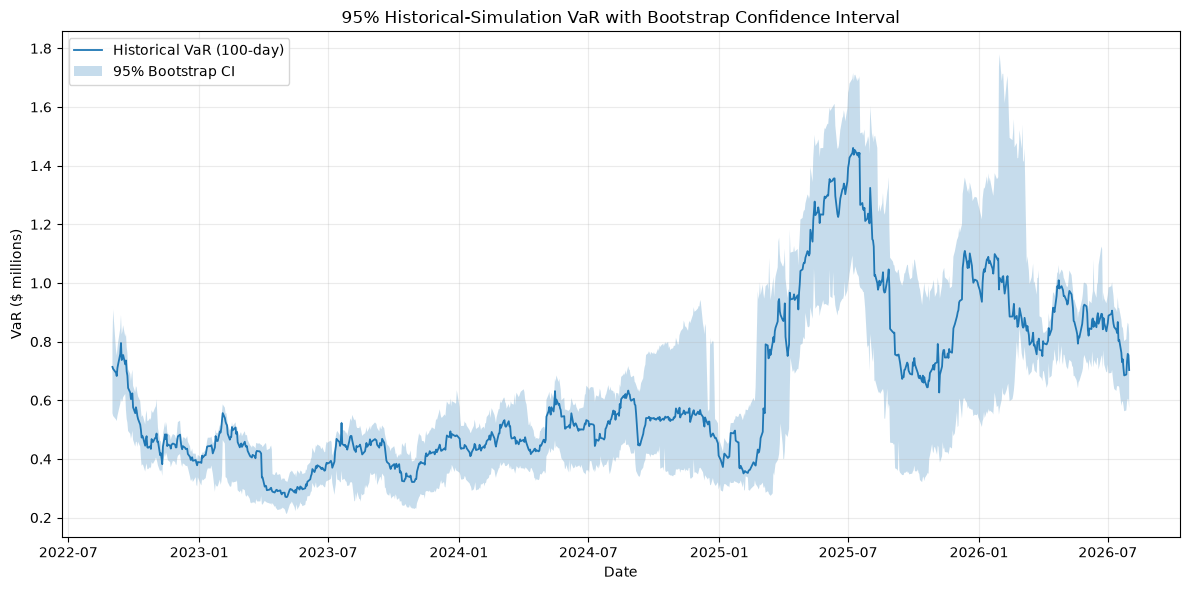

Saved figure: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q05_bootstrap_ci_100.png


In [24]:
# ============================================================
# QUESTION 5 — BOOTSTRAP CONFIDENCE INTERVAL
# Historical Simulation VaR
# 100-Day Rolling Window
# ============================================================

print("=" * 70)
print("QUESTION 5 — BOOTSTRAP CONFIDENCE INTERVAL")
print("=" * 70)


# ------------------------------------------------------------
# 1. Bootstrap parameters
# ------------------------------------------------------------

BOOT_WINDOW = 100
BOOT_CONFIDENCE = 0.95
BOOT_ALPHA = 1 - BOOT_CONFIDENCE

N_BOOT = 1000
BOOT_CI = 0.95

BOOT_SEED = 230

rng_boot = np.random.default_rng(
    BOOT_SEED
)

print(f"Rolling window       : {BOOT_WINDOW}")
print(f"VaR confidence level : {BOOT_CONFIDENCE:.0%}")
print(f"Bootstrap repetitions: {N_BOOT:,}")
print(f"Bootstrap CI         : {BOOT_CI:.0%}")
print(f"Random seed          : {BOOT_SEED}")


# ------------------------------------------------------------
# 2. Prepare return data
# ------------------------------------------------------------

bootstrap_returns = returns_q2[
    TICKERS
].copy()

bootstrap_forecast_dates = bootstrap_returns.loc[
    FORECAST_START:FORECAST_END
].index

print(
    "\nNumber of bootstrap forecast dates:",
    len(bootstrap_forecast_dates)
)


# ------------------------------------------------------------
# 3. Rolling bootstrap calculation
# ------------------------------------------------------------

bootstrap_results = []

for forecast_date in bootstrap_forecast_dates:

    loc = bootstrap_returns.index.get_loc(
        forecast_date
    )

    # Need exactly 100 observations BEFORE forecast date
    if loc < BOOT_WINDOW:
        continue

    # --------------------------------------------------------
    # Previous 100 stock-return observations
    # --------------------------------------------------------

    estimation_window = bootstrap_returns.iloc[
        loc - BOOT_WINDOW:loc
    ]

    previous_date = bootstrap_returns.index[
        loc - 1
    ]

    # Portfolio weights at t-1
    current_weights = daily_weights.loc[
        previous_date,
        TICKERS
    ].values

    # Portfolio value at t-1
    current_portfolio_value = portfolio_value.loc[
        previous_date
    ]

    # --------------------------------------------------------
    # 4. Historical portfolio-return scenarios
    # --------------------------------------------------------

    historical_portfolio_returns = (
        estimation_window.values
        @ current_weights
    )

    # Original historical VaR
    original_quantile = np.quantile(
        historical_portfolio_returns,
        BOOT_ALPHA
    )

    original_var_return = (
        -original_quantile
    )

    original_var_dollar = (
        original_var_return
        * current_portfolio_value
    )


    # --------------------------------------------------------
    # 5. Generate bootstrap samples
    # --------------------------------------------------------

    # Shape:
    # N_BOOT x BOOT_WINDOW
    bootstrap_samples = rng_boot.choice(
        historical_portfolio_returns,
        size=(
            N_BOOT,
            BOOT_WINDOW
        ),
        replace=True
    )


    # --------------------------------------------------------
    # 6. VaR for each bootstrap sample
    # --------------------------------------------------------

    bootstrap_quantiles = np.quantile(
        bootstrap_samples,
        BOOT_ALPHA,
        axis=1
    )

    bootstrap_vars = (
        -bootstrap_quantiles
    )


    # --------------------------------------------------------
    # 7. 95% percentile confidence interval
    # --------------------------------------------------------

    lower_probability = (
        (1 - BOOT_CI) / 2
    )

    upper_probability = (
        1 - lower_probability
    )

    ci_lower_return = np.quantile(
        bootstrap_vars,
        lower_probability
    )

    ci_upper_return = np.quantile(
        bootstrap_vars,
        upper_probability
    )


    # --------------------------------------------------------
    # 8. Convert CI to dollar terms
    # --------------------------------------------------------

    ci_lower_dollar = (
        ci_lower_return
        * current_portfolio_value
    )

    ci_upper_dollar = (
        ci_upper_return
        * current_portfolio_value
    )

    bootstrap_std_return = (
        np.std(
            bootstrap_vars,
            ddof=1
        )
    )

    bootstrap_std_dollar = (
        bootstrap_std_return
        * current_portfolio_value
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    bootstrap_results.append({

        "date":
            forecast_date,

        "previous_date":
            previous_date,

        "portfolio_value":
            current_portfolio_value,

        "historical_var_return_100":
            original_var_return,

        "historical_var_dollar_100":
            original_var_dollar,

        "bootstrap_ci_lower_return_100":
            ci_lower_return,

        "bootstrap_ci_upper_return_100":
            ci_upper_return,

        "bootstrap_ci_lower_dollar_100":
            ci_lower_dollar,

        "bootstrap_ci_upper_dollar_100":
            ci_upper_dollar,

        "bootstrap_std_return_100":
            bootstrap_std_return,

        "bootstrap_std_dollar_100":
            bootstrap_std_dollar
    })


# ------------------------------------------------------------
# 9. Convert results to DataFrame
# ------------------------------------------------------------

bootstrap_ci_100 = pd.DataFrame(
    bootstrap_results
).set_index("date")


# ------------------------------------------------------------
# 10. Inspect results
# ------------------------------------------------------------

print(
    "\nBootstrap confidence-interval results:"
)

display(
    bootstrap_ci_100[
        [
            "historical_var_dollar_100",
            "bootstrap_ci_lower_dollar_100",
            "bootstrap_ci_upper_dollar_100",
            "bootstrap_std_dollar_100"
        ]
    ].head()
)


# ------------------------------------------------------------
# 11. Summary statistics
# ------------------------------------------------------------

bootstrap_summary_100 = (
    bootstrap_ci_100[
        [
            "historical_var_return_100",
            "bootstrap_ci_lower_return_100",
            "bootstrap_ci_upper_return_100",
            "historical_var_dollar_100",
            "bootstrap_ci_lower_dollar_100",
            "bootstrap_ci_upper_dollar_100"
        ]
    ]
    .describe()
)

print(
    "\nSummary statistics:"
)

display(
    bootstrap_summary_100
)


# ------------------------------------------------------------
# 12. Calculate average CI width
# ------------------------------------------------------------

bootstrap_ci_100[
    "ci_width_return_100"
] = (
    bootstrap_ci_100[
        "bootstrap_ci_upper_return_100"
    ]
    -
    bootstrap_ci_100[
        "bootstrap_ci_lower_return_100"
    ]
)

bootstrap_ci_100[
    "ci_width_dollar_100"
] = (
    bootstrap_ci_100[
        "bootstrap_ci_upper_dollar_100"
    ]
    -
    bootstrap_ci_100[
        "bootstrap_ci_lower_dollar_100"
    ]
)

print(
    "\nAverage 95% CI width (return):",
    f"{bootstrap_ci_100['ci_width_return_100'].mean():.4%}"
)

print(
    "Average 95% CI width (dollar):",
    f"${bootstrap_ci_100['ci_width_dollar_100'].mean():,.0f}"
)


# ------------------------------------------------------------
# 13. Save full bootstrap results
# ------------------------------------------------------------

bootstrap_ci_100.to_csv(
    DATA_PROCESSED /
    "Q05_bootstrap_ci_100.csv"
)

print(
    "\nSaved:",
    DATA_PROCESSED /
    "Q05_bootstrap_ci_100.csv"
)


# ------------------------------------------------------------
# 14. Save summary table
# ------------------------------------------------------------

bootstrap_summary_100.T.to_csv(
    TABLES /
    "Q05_bootstrap_ci_100_summary.csv"
)

print(
    "Saved:",
    TABLES /
    "Q05_bootstrap_ci_100_summary.csv"
)


# ------------------------------------------------------------
# 15. Plot historical VaR and 95% bootstrap CI
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

# Historical-simulation VaR
ax.plot(
    bootstrap_ci_100.index,
    bootstrap_ci_100[
        "historical_var_dollar_100"
    ] / 1_000_000,
    linewidth=1.3,
    label="Historical VaR (100-day)"
)

# Bootstrap confidence interval
ax.fill_between(
    bootstrap_ci_100.index,
    bootstrap_ci_100[
        "bootstrap_ci_lower_dollar_100"
    ] / 1_000_000,
    bootstrap_ci_100[
        "bootstrap_ci_upper_dollar_100"
    ] / 1_000_000,
    alpha=0.25,
    label="95% Bootstrap CI"
)

ax.set_title(
    "95% Historical-Simulation VaR "
    "with Bootstrap Confidence Interval"
)

ax.set_xlabel("Date")

ax.set_ylabel(
    "VaR ($ millions)"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()


# ------------------------------------------------------------
# 16. Save figure
# ------------------------------------------------------------

bootstrap_figure_path = (
    FIGURES /
    "Q05_bootstrap_ci_100.png"
)

plt.savefig(
    bootstrap_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    bootstrap_figure_path
)

## Q 5 — Results and Interpretation
Using the 100-day rolling historical-simulation VaR from Question 3, I constructed 95% bootstrap confidence intervals using 1,000 bootstrap replications for each of the 981 forecast dates. The assignment asks for a 95% bootstrap confidence interval around the VaR forecasts.
For September 1, 2022, the historical-simulation VaR was approximately
$$ {\$713{,}907}. $$
The corresponding 95% bootstrap confidence interval was approximately
$$ { [\$556{,}198,\ \ \$797{,}807] }. $$
This interval shows the sampling uncertainty around the VaR estimate obtained from a 100-day historical window.
Across the full forecast period, the average historical VaR was approximately 3.98% of portfolio value, while the average lower and upper bounds of the bootstrap interval were approximately 2.88% and 4.84%, respectively. In dollar terms, the average lower bound was approximately
$$ {\$450{,}503}, $$
and the average upper bound was approximately
$$ {\$786{,}566}. $$
The average width of the 95% confidence interval was approximately 1.96 percentage points of portfolio value, or about
$$ {\$336{,}064}. $$
The relatively wide confidence intervals indicate that the 100-day historical VaR estimate contains meaningful sampling uncertainty. Because VaR is determined by observations in the lower tail of the return distribution, a relatively small number of extreme returns can materially affect the estimate. The confidence interval therefore provides useful information beyond the point estimate alone by showing how precisely the historical VaR is estimated.
Overall, the bootstrap results suggest that the estimated VaR is time-varying and subject to substantial uncertainty, especially during periods when the recent return distribution contains large negative observations. This will be useful when comparing the 100-day results with the longer 500-day window in Question 6.

# 6. Larger rolling window

Repeat Questions 3–5 using a **500-day rolling window**.

We will produce separate 500-day figures and tables so the 100-day and 500-day results can be compared directly.

## Q 6 — Code Process
Add this as a Markdown cell before the code.
1. Change the rolling window to 500 days.
All methods remain the same as in Questions 3–5, but each forecast now uses the previous 500 trading days instead of 100.
2. Historical-simulation VaR.
For each forecast date, apply the portfolio weights at \(t-1\) to the previous 500 historical stock-return scenarios:
$$ r_{p,s}^{(t)} = w_{t-1}^{\top}r_s. $$
The 95% historical VaR is
$$ VaR_{t,95\%}^{HS} = -Q_{0.05}(r_p). $$
3. Marginal VaR.
For GME and DKS, increase the selected stock's weight by one percentage point, proportionally reduce the remaining weights, and recalculate historical VaR. The change in VaR is used to estimate marginal VaR.
4. Bootstrap confidence interval.
For every forecast date, resample the 500 historical portfolio-return scenarios with replacement 1,000 times. Recalculate the 95% VaR for each bootstrap sample and obtain the 95% CI from the 2.5th and 97.5th percentiles.
5. Save and plot the results.
The 500-day VaR, marginal VaR, and bootstrap confidence intervals are saved separately so they can later be compared directly with the 100-day estimates.

In [25]:
# ============================================================
# QUESTION 6 — LARGE ROLLING WINDOW
# Repeat Questions 3–5 Using a 500-Day Window
# ============================================================

print("=" * 70)
print("QUESTION 6 — 500-DAY ROLLING WINDOW")
print("=" * 70)


# ============================================================
# PARAMETERS
# ============================================================

WINDOW_500 = 500
CONFIDENCE_500 = 0.95
ALPHA_500 = 1 - CONFIDENCE_500

N_BOOT_500 = 1000
BOOT_CI_500 = 0.95
BOOT_SEED_500 = 230

DELTA_WEIGHT_500 = 0.01

MARGINAL_STOCKS_500 = [
    "GME",
    "DKS"
]

rng_boot_500 = np.random.default_rng(
    BOOT_SEED_500
)

print(f"Rolling window       : {WINDOW_500}")
print(f"Confidence level     : {CONFIDENCE_500:.0%}")
print(f"Bootstrap repetitions: {N_BOOT_500:,}")
print(f"Marginal stocks      : {MARGINAL_STOCKS_500}")

QUESTION 6 — 500-DAY ROLLING WINDOW
Rolling window       : 500
Confidence level     : 95%
Bootstrap repetitions: 1,000
Marginal stocks      : ['GME', 'DKS']


In [ ]:
## Q 6 a

In [26]:
# ============================================================
# QUESTION 6A — HISTORICAL VaR
# 500-Day Rolling Window
# ============================================================


# ------------------------------------------------------------
# 1. Prepare return data
# ------------------------------------------------------------

returns_500 = returns_q2[
    TICKERS
].copy()

forecast_dates_500 = returns_500.loc[
    FORECAST_START:FORECAST_END
].index

print(
    "\nNumber of forecast dates:",
    len(forecast_dates_500)
)


# ------------------------------------------------------------
# 2. Rolling 500-day historical VaR
# ------------------------------------------------------------

historical_results_500 = []

for forecast_date in forecast_dates_500:

    loc = returns_500.index.get_loc(
        forecast_date
    )

    # Need exactly 500 prior observations
    if loc < WINDOW_500:
        continue

    estimation_window = returns_500.iloc[
        loc - WINDOW_500:loc
    ]

    previous_date = returns_500.index[
        loc - 1
    ]

    # Current portfolio weights at t-1
    current_weights = daily_weights.loc[
        previous_date,
        TICKERS
    ].values

    # Current portfolio value at t-1
    current_portfolio_value = portfolio_value.loc[
        previous_date
    ]

    # Historical portfolio scenarios
    historical_portfolio_returns = (
        estimation_window.values
        @ current_weights
    )

    # Empirical 5th percentile
    lower_quantile = np.quantile(
        historical_portfolio_returns,
        ALPHA_500
    )

    historical_var_return_500 = (
        -lower_quantile
    )

    historical_var_dollar_500 = (
        historical_var_return_500
        * current_portfolio_value
    )

    historical_results_500.append({

        "date":
            forecast_date,

        "previous_date":
            previous_date,

        "portfolio_value":
            current_portfolio_value,

        "historical_var_return_500":
            historical_var_return_500,

        "historical_var_dollar_500":
            historical_var_dollar_500
    })


historical_var_500 = pd.DataFrame(
    historical_results_500
).set_index("date")


# ------------------------------------------------------------
# 3. Inspect results
# ------------------------------------------------------------

print("\n500-day Historical VaR:")

display(
    historical_var_500.head()
)

historical_summary_500 = (
    historical_var_500[
        [
            "historical_var_return_500",
            "historical_var_dollar_500"
        ]
    ]
    .describe()
)

print("\nSummary statistics:")

display(
    historical_summary_500
)


# ------------------------------------------------------------
# 4. Save results
# ------------------------------------------------------------

historical_var_500.to_csv(
    DATA_PROCESSED /
    "Q06_historical_var_500.csv"
)

historical_summary_500.T.to_csv(
    TABLES /
    "Q06_historical_var_500_summary.csv"
)

print(
    "Saved:",
    DATA_PROCESSED /
    "Q06_historical_var_500.csv"
)

print(
    "Saved:",
    TABLES /
    "Q06_historical_var_500_summary.csv"
)


Number of forecast dates: 981

500-day Historical VaR:


,previous_date,portfolio_value,historical_var_return_500,historical_var_dollar_500
date,,,,
2022-09-01,2022-08-31,1.000000e+07,0.048866,488659.059241
2022-09-02,2022-09-01,9.910863e+06,0.048896,484600.310431
2022-09-06,2022-09-02,9.765569e+06,0.048512,473751.721688
2022-09-07,2022-09-06,9.545856e+06,0.048419,462197.318826
2022-09-08,2022-09-07,9.866089e+06,0.048333,476853.076192



Summary statistics:


,historical_var_return_500,historical_var_dollar_500
count,981.000000,9.810000e+02
mean,0.048884,7.815282e+05
std,0.004301,2.396492e+05
min,0.039452,3.504058e+05
25%,0.045776,5.819187e+05
50%,0.048676,7.908442e+05
75%,0.052292,9.542734e+05
max,0.059662,1.331423e+06


Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/processed/Q06_historical_var_500.csv
Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q06_historical_var_500_summary.csv


In [27]:
### 6B. Marginal VaR — 500-Day Window

In [28]:

# ============================================================
# QUESTION 6B — MARGINAL VaR
# 500-Day Historical Simulation
# ============================================================

mvar_results_500 = []


for forecast_date in forecast_dates_500:

    loc = returns_500.index.get_loc(
        forecast_date
    )

    if loc < WINDOW_500:
        continue

    estimation_window = returns_500.iloc[
        loc - WINDOW_500:loc
    ]

    previous_date = returns_500.index[
        loc - 1
    ]

    current_weights = daily_weights.loc[
        previous_date,
        TICKERS
    ].values

    current_portfolio_value = portfolio_value.loc[
        previous_date
    ]


    # --------------------------------------------------------
    # Base historical VaR
    # --------------------------------------------------------

    base_returns = (
        estimation_window.values
        @ current_weights
    )

    base_quantile = np.quantile(
        base_returns,
        ALPHA_500
    )

    base_var_return = (
        -base_quantile
    )

    base_var_dollar = (
        base_var_return
        * current_portfolio_value
    )


    result = {

        "date":
            forecast_date,

        "previous_date":
            previous_date,

        "portfolio_value":
            current_portfolio_value,

        "base_var_return":
            base_var_return,

        "base_var_dollar":
            base_var_dollar
    }


    # --------------------------------------------------------
    # Marginal VaR: GME and DKS
    # --------------------------------------------------------

    for ticker in MARGINAL_STOCKS_500:

        target_index = TICKERS.index(
            ticker
        )

        perturbed_weights = perturb_weight(
            current_weights,
            target_index,
            DELTA_WEIGHT_500
        )

        perturbed_returns = (
            estimation_window.values
            @ perturbed_weights
        )

        perturbed_quantile = np.quantile(
            perturbed_returns,
            ALPHA_500
        )

        perturbed_var_return = (
            -perturbed_quantile
        )


        # Marginal VaR sensitivity
        marginal_var_return = (
            perturbed_var_return
            - base_var_return
        ) / DELTA_WEIGHT_500


        marginal_var_dollar = (
            marginal_var_return
            * current_portfolio_value
        )


        # Dollar change from +1 percentage point
        var_change_1pct = (
            perturbed_var_return
            - base_var_return
        )

        var_change_1pct_dollar = (
            var_change_1pct
            * current_portfolio_value
        )


        result[
            f"marginal_var_{ticker}"
        ] = marginal_var_return

        result[
            f"marginal_var_dollar_{ticker}"
        ] = marginal_var_dollar

        result[
            f"var_change_1pct_{ticker}"
        ] = var_change_1pct

        result[
            f"var_change_1pct_dollar_{ticker}"
        ] = var_change_1pct_dollar


    mvar_results_500.append(
        result
    )


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

marginal_var_500 = pd.DataFrame(
    mvar_results_500
).set_index("date")


# ------------------------------------------------------------
# Inspect
# ------------------------------------------------------------

print("\n500-day Marginal VaR:")

display(
    marginal_var_500[
        [
            "marginal_var_GME",
            "marginal_var_DKS",
            "var_change_1pct_dollar_GME",
            "var_change_1pct_dollar_DKS"
        ]
    ].head()
)


mvar_summary_500 = (
    marginal_var_500[
        [
            "marginal_var_GME",
            "marginal_var_DKS",
            "var_change_1pct_dollar_GME",
            "var_change_1pct_dollar_DKS"
        ]
    ]
    .describe()
)

print("\nMarginal VaR summary:")

display(
    mvar_summary_500
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

marginal_var_500.to_csv(
    DATA_PROCESSED /
    "Q06_marginal_var_500.csv"
)

mvar_summary_500.T.to_csv(
    TABLES /
    "Q06_marginal_var_500_summary.csv"
)

print(
    "Saved:",
    DATA_PROCESSED /
    "Q06_marginal_var_500.csv"
)



500-day Marginal VaR:


,marginal_var_GME,marginal_var_DKS,var_change_1pct_dollar_GME,var_change_1pct_dollar_DKS
date,,,,
2022-09-01,0.009623,-0.029135,962.349262,-2913.509383
2022-09-02,0.009611,-0.047345,952.568627,-4692.318969
2022-09-06,0.020486,-0.052159,2000.581467,-5093.626346
2022-09-07,0.021632,-0.050063,2064.965257,-4778.980915
2022-09-08,0.019732,-0.050076,1946.808679,-4940.547410



Marginal VaR summary:


,marginal_var_GME,marginal_var_DKS,var_change_1pct_dollar_GME,var_change_1pct_dollar_DKS
count,981.000000,981.000000,981.000000,981.000000
mean,-0.005292,-0.029076,-1331.617538,-4959.953784
std,0.035573,0.019593,6629.896634,3740.540185
min,-0.135622,-0.079252,-32949.423519,-15270.259313
25%,-0.025999,-0.042617,-4935.000825,-7770.381262
50%,-0.009077,-0.029878,-1175.164520,-5114.970935
75%,0.012533,-0.018438,1635.054921,-2247.920548
max,0.159233,0.154318,35468.620625,24449.247388


Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/data/processed/Q06_marginal_var_500.csv


In [ ]:
### 6C. Bootstrap 95% Confidence Interval — 500-Day Window
### This portion will be the slowest because every forecast date requires 1,000 bootstrap samples of 500 observations.

In [29]:
# ============================================================
# QUESTION 6C — BOOTSTRAP CONFIDENCE INTERVAL
# 500-Day Rolling Window
# ============================================================

bootstrap_results_500 = []


for forecast_date in forecast_dates_500:

    loc = returns_500.index.get_loc(
        forecast_date
    )

    if loc < WINDOW_500:
        continue

    estimation_window = returns_500.iloc[
        loc - WINDOW_500:loc
    ]

    previous_date = returns_500.index[
        loc - 1
    ]

    current_weights = daily_weights.loc[
        previous_date,
        TICKERS
    ].values

    current_portfolio_value = portfolio_value.loc[
        previous_date
    ]


    # --------------------------------------------------------
    # Historical portfolio returns
    # --------------------------------------------------------

    historical_portfolio_returns = (
        estimation_window.values
        @ current_weights
    )


    # Original VaR
    original_quantile = np.quantile(
        historical_portfolio_returns,
        ALPHA_500
    )

    original_var_return = (
        -original_quantile
    )

    original_var_dollar = (
        original_var_return
        * current_portfolio_value
    )


    # --------------------------------------------------------
    # Bootstrap samples
    # --------------------------------------------------------

    bootstrap_samples = rng_boot_500.choice(
        historical_portfolio_returns,
        size=(
            N_BOOT_500,
            WINDOW_500
        ),
        replace=True
    )


    # VaR for every bootstrap sample
    bootstrap_quantiles = np.quantile(
        bootstrap_samples,
        ALPHA_500,
        axis=1
    )

    bootstrap_vars = (
        -bootstrap_quantiles
    )


    # --------------------------------------------------------
    # 95% confidence interval
    # --------------------------------------------------------

    ci_lower_return = np.quantile(
        bootstrap_vars,
        0.025
    )

    ci_upper_return = np.quantile(
        bootstrap_vars,
        0.975
    )


    ci_lower_dollar = (
        ci_lower_return
        * current_portfolio_value
    )

    ci_upper_dollar = (
        ci_upper_return
        * current_portfolio_value
    )


    bootstrap_results_500.append({

        "date":
            forecast_date,

        "previous_date":
            previous_date,

        "portfolio_value":
            current_portfolio_value,

        "historical_var_return_500":
            original_var_return,

        "historical_var_dollar_500":
            original_var_dollar,

        "bootstrap_ci_lower_return_500":
            ci_lower_return,

        "bootstrap_ci_upper_return_500":
            ci_upper_return,

        "bootstrap_ci_lower_dollar_500":
            ci_lower_dollar,

        "bootstrap_ci_upper_dollar_500":
            ci_upper_dollar
    })


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

bootstrap_ci_500 = pd.DataFrame(
    bootstrap_results_500
).set_index("date")


# ------------------------------------------------------------
# Calculate CI width
# ------------------------------------------------------------

bootstrap_ci_500[
    "ci_width_return_500"
] = (
    bootstrap_ci_500[
        "bootstrap_ci_upper_return_500"
    ]
    -
    bootstrap_ci_500[
        "bootstrap_ci_lower_return_500"
    ]
)

bootstrap_ci_500[
    "ci_width_dollar_500"
] = (
    bootstrap_ci_500[
        "bootstrap_ci_upper_dollar_500"
    ]
    -
    bootstrap_ci_500[
        "bootstrap_ci_lower_dollar_500"
    ]
)


# ------------------------------------------------------------
# Inspect
# ------------------------------------------------------------

print(
    "\n500-day Bootstrap CI:"
)

display(
    bootstrap_ci_500[
        [
            "historical_var_dollar_500",
            "bootstrap_ci_lower_dollar_500",
            "bootstrap_ci_upper_dollar_500"
        ]
    ].head()
)


bootstrap_summary_500 = (
    bootstrap_ci_500[
        [
            "historical_var_return_500",
            "bootstrap_ci_lower_return_500",
            "bootstrap_ci_upper_return_500",
            "historical_var_dollar_500",
            "bootstrap_ci_lower_dollar_500",
            "bootstrap_ci_upper_dollar_500"
        ]
    ]
    .describe()
)

print("\nBootstrap summary:")

display(
    bootstrap_summary_500
)


print(
    "\nAverage 95% CI width (return):",
    f"{bootstrap_ci_500['ci_width_return_500'].mean():.4%}"
)

print(
    "Average 95% CI width (dollar):",
    f"${bootstrap_ci_500['ci_width_dollar_500'].mean():,.0f}"
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

bootstrap_ci_500.to_csv(
    DATA_PROCESSED /
    "Q06_bootstrap_ci_500.csv"
)

bootstrap_summary_500.T.to_csv(
    TABLES /
    "Q06_bootstrap_ci_500_summary.csv"
)


500-day Bootstrap CI:


,historical_var_dollar_500,bootstrap_ci_lower_dollar_500,bootstrap_ci_upper_dollar_500
date,,,
2022-09-01,488659.059241,440997.199565,566337.256172
2022-09-02,484600.310431,438547.625933,568114.219514
2022-09-06,473751.721688,429904.578069,546945.146853
2022-09-07,462197.318826,419452.625129,538738.367973
2022-09-08,476853.076192,433516.752370,543248.150052



Bootstrap summary:


,historical_var_return_500,bootstrap_ci_lower_return_500,bootstrap_ci_upper_return_500,historical_var_dollar_500,bootstrap_ci_lower_dollar_500,bootstrap_ci_upper_dollar_500
count,981.000000,981.000000,981.000000,9.810000e+02,9.810000e+02,9.810000e+02
mean,0.048884,0.042847,0.054634,7.815282e+05,6.797303e+05,8.742077e+05
std,0.004301,0.004384,0.004681,2.396492e+05,1.950387e+05,2.665942e+05
min,0.039452,0.032255,0.045549,3.504058e+05,3.219185e+05,3.967931e+05
25%,0.045776,0.038767,0.050730,5.819187e+05,5.188487e+05,6.338944e+05
50%,0.048676,0.043684,0.054100,7.908442e+05,6.879225e+05,8.987151e+05
75%,0.052292,0.045656,0.058689,9.542734e+05,8.331260e+05,1.103238e+06
max,0.059662,0.050691,0.068089,1.331423e+06,1.108332e+06,1.452595e+06



Average 95% CI width (return): 1.1786%
Average 95% CI width (dollar): $194,477


In [30]:
## 6D. Plot 500-Day Historical VaR with Bootstrap CI
## This should be one of the main Question 6 figures because it follows the layout shown in the assignment sample.

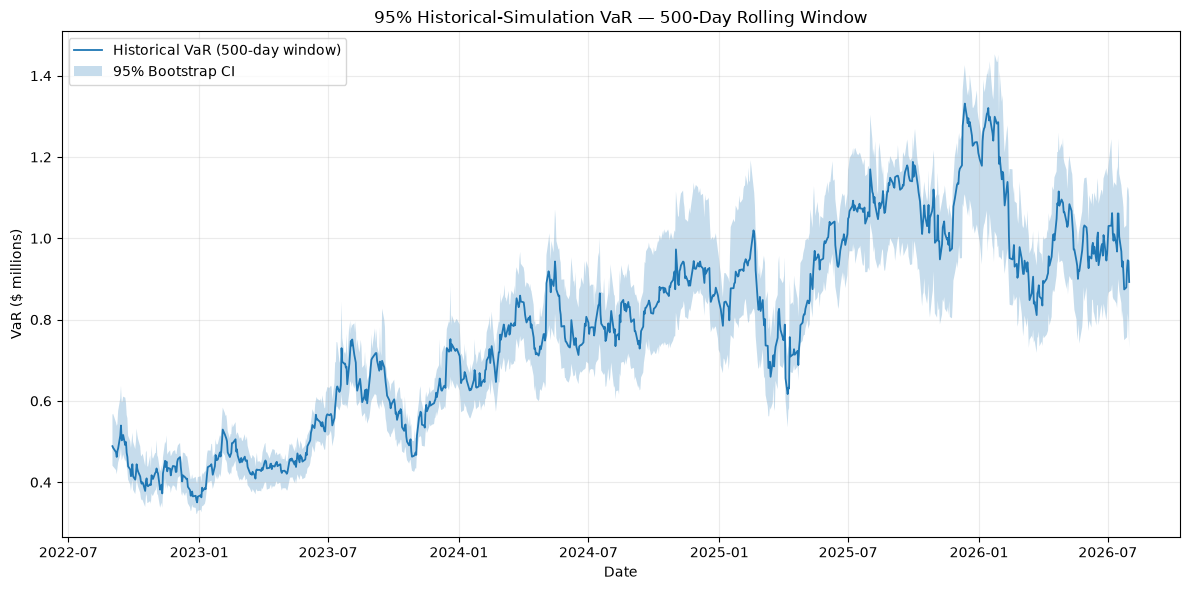

Saved figure: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q06_historical_var_500.png


In [32]:
# ============================================================
# FIGURE — 500-DAY VaR + 95% BOOTSTRAP CI
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    bootstrap_ci_500.index,
    bootstrap_ci_500[
        "historical_var_dollar_500"
    ] / 1_000_000,
    linewidth=1.3,
    label="Historical VaR (500-day window)"
)

ax.fill_between(
    bootstrap_ci_500.index,
    bootstrap_ci_500[
        "bootstrap_ci_lower_dollar_500"
    ] / 1_000_000,
    bootstrap_ci_500[
        "bootstrap_ci_upper_dollar_500"
    ] / 1_000_000,
    alpha=0.25,
    label="95% Bootstrap CI"
)

ax.set_title(
    "95% Historical-Simulation VaR "
    "— 500-Day Rolling Window"
)

ax.set_xlabel("Date")
ax.set_ylabel("VaR ($ millions)")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()

var500_figure_path = (
    FIGURES /
    "Q06_historical_var_500.png"
)

plt.savefig(
    var500_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    var500_figure_path
)

In [33]:
### 6E. Plot 500-Day Marginal VaR


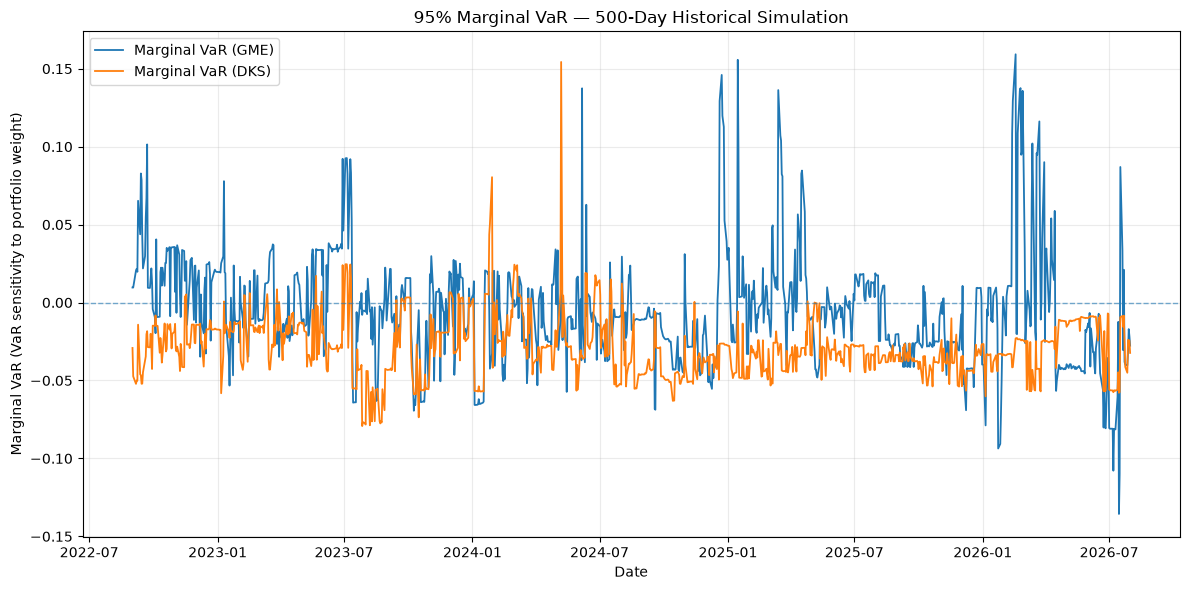

Saved figure: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q06_marginal_var_500.png


In [34]:
# ============================================================
# FIGURE — 500-DAY MARGINAL VaR
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    marginal_var_500.index,
    marginal_var_500[
        "marginal_var_GME"
    ],
    linewidth=1.3,
    label="Marginal VaR (GME)"
)

ax.plot(
    marginal_var_500.index,
    marginal_var_500[
        "marginal_var_DKS"
    ],
    linewidth=1.3,
    label="Marginal VaR (DKS)"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_title(
    "95% Marginal VaR — "
    "500-Day Historical Simulation"
)

ax.set_xlabel("Date")

ax.set_ylabel(
    "Marginal VaR "
    "(VaR sensitivity to portfolio weight)"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()

mvar500_figure_path = (
    FIGURES /
    "Q06_marginal_var_500.png"
)

plt.savefig(
    mvar500_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure:",
    mvar500_figure_path
)


## Q 6 — Interpretation of the 500-Day Rolling Window

Using a **500-trading-day rolling window** changes the risk estimates substantially relative to the 100-day window. Because the longer window incorporates approximately two years of historical observations, the estimates are less sensitive to short-term changes in market volatility and therefore evolve more smoothly through time.

### Historical-Simulation VaR

The average 95% Historical-Simulation VaR using the 500-day window is approximately **4.89% of portfolio value**, corresponding to an average dollar VaR of approximately **$781,528**. The median dollar VaR is approximately **$790,844**, while the maximum observed VaR is approximately **$1.331 million**.

For September 1, 2022, the 500-day Historical VaR is approximately **$488,659**, substantially below the **$713,907** obtained using the 100-day window. This occurs because the 500-day window includes a much longer history and therefore places less emphasis on the relatively volatile observations immediately preceding the forecast date.

Over the full forecasting period, however, the average 500-day VaR is higher than the average 100-day VaR:

| Measure | 100-Day Window | 500-Day Window |
|---|---:|---:|
| Mean VaR return | 3.98% | 4.89% |
| Mean dollar VaR | $634,924 | $781,528 |
| Maximum dollar VaR | $1.460 million | $1.331 million |
| Sep. 1, 2022 VaR | $713,907 | $488,659 |

The longer window therefore does not necessarily produce a lower VaR. Instead, it produces a **more persistent and smoother estimate** because older high-volatility periods remain in the historical sample for much longer.

### Bootstrap Confidence Interval

The 500-day bootstrap estimates are considerably more precise. The average width of the 95% bootstrap confidence interval is approximately **1.18% of portfolio value**, or about **$194,477**.

By comparison, the corresponding 100-day confidence interval had an average width of approximately **1.96%**, or **$336,064**.

| Bootstrap Measure | 100-Day Window | 500-Day Window |
|---|---:|---:|
| Average CI width — return | 1.96% | 1.18% |
| Average CI width — dollar | $336,064 | $194,477 |

The narrower confidence interval is expected because the 500-day historical sample contains five times as many observations. Consequently, the empirical 5th-percentile estimate is based on substantially more information and is less affected by individual observations.

The figure also shows that the VaR path and its confidence band are smoother under the 500-day specification. This represents a trade-off: the estimate is **statistically more stable**, but it reacts more slowly when market conditions change.

### Marginal VaR

The 500-day Marginal VaR results also become smoother, although the sensitivities of individual securities continue to vary through time.

The average Marginal VaR sensitivities are:

| Stock | 100-Day Mean Marginal VaR | 500-Day Mean Marginal VaR |
|---|---:|---:|
| GME | -0.00792 | -0.00529 |
| DKS | -0.02454 | -0.02908 |

For **GME**, the average marginal effect becomes closer to zero with the longer window, indicating that its incremental contribution to portfolio VaR is less pronounced on average under the long-run covariance structure.

For **DKS**, the average marginal effect becomes somewhat more negative. Under the sign convention used in this analysis, a **negative Marginal VaR means that increasing the stock's portfolio weight slightly decreases the estimated portfolio VaR**, while a positive value means that the additional weight increases VaR.

The figure shows that GME has considerably greater variation in its marginal contribution, including several large positive and negative spikes. DKS is generally more stable and remains negative for most of the sample, although it also experiences occasional positive spikes.

### Conclusion

Increasing the rolling window from 100 to 500 trading days produces three important effects:

1. **VaR becomes smoother and more persistent** because the estimate uses a much longer historical record.
2. **Bootstrap uncertainty falls substantially**, with the average dollar confidence-interval width declining from approximately $336,064 to $194,477.
3. **Marginal VaR becomes less responsive to short-lived market movements**, although the risk contribution of individual securities can still vary materially through time.

Therefore, the 500-day window provides a more statistically stable estimate of portfolio risk, while the 100-day window is more responsive to recent changes in market conditions. Neither window is universally superior; the choice represents a trade-off between **responsiveness and estimation stability**.

# 7. Export for Notebook 2

At the end of Notebook 1, save a master daily results file to:

```text
data/processed/var_forecasts.csv
```

Planned columns include:

- date
- portfolio return
- portfolio loss
- parametric VaR (100-day)
- historical VaR (100-day)
- historical VaR (500-day)
- bootstrap lower/upper bounds
- marginal VaR series

Notebook 2 will read this file for **Question 7 backtesting** and **Question 8 discussion**.

In [ ]:
# Final export will be added once all Q1–Q6 calculations are complete.